# Vollständig trainierte Modelle – Evaluation

Dieses Notebook evaluiert **fünf Modelle** (LightGBM, GRU, RandomForest, iTransformer, CNN-LSTM),
die auf **allen ~2900 Spots** trainiert wurden.

Inhalte:
0. Test-Set Metriken (interner Split)
1. Punktvorhersage-Metriken (OOS) (MAE, wMAE, RMSE, wRMSE, R²)
4. Kalibrierungsplot (Reliability Diagram)
5. Vorhersageintervall-Beispiel (12h-Fenster)
6. Feature Importance (Gini/Split für Baummodelle, Permutation für DL-Modelle)
7. Horizont-Analyse (Vorhersagefehler vs. Lead-Time + Zeitreihenplot 3 Spots)
8. Inferenzzeit & Stromkosten (65W CPU, 37 ct/kWh, 1M Predictions)
9. UMBRA Batterieoptimierung
10. MLflow Logging
11. Zusammenfassung-Tabelle

In [98]:
from pathlib import Path
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Paths ─────────────────────────────────────────────────────────────────────
_here = Path.cwd()
if (_here / 'bscthesis').exists():
    _BASE     = _here / 'bscthesis'
    _EXP_BASE = _here / 'experiments'
else:
    _BASE     = _here
    _EXP_BASE = _here.parent / 'experiments'

FULL_DIR     = _BASE / 'fulltrainedmodels'
LGB_DIR      = FULL_DIR / 'lightgbm_results'
GRU_DIR      = FULL_DIR / 'gru_results'
RF_DIR       = FULL_DIR / 'random_forest_results'
ITR_DIR      = FULL_DIR / 'i_transformer_results'
CNN_DIR      = FULL_DIR / 'cnn_lstm_results'
DATA_PATH    = _BASE / 'data' / 'processed' / 'data_final.parquet'
OOS_PATH     = _BASE / 'data' / 'processed' / 'unseen_data.parquet'
DATA_10_PATH = _BASE / 'data' / 'raw' / '2026_03_10'
SPT_PATH     = _EXP_BASE / 'total_pv_output' / 'data' / 'processed' / '2026-03-03_pv_with_analogs.parquet'
RESULTS_DIR  = _BASE / 'modelresults'
RESULTS_DIR.mkdir(exist_ok=True)

PALETTE = {
    'LightGBM-Full':     '#f28e2b',
    'GRU-Full':          '#76b7b2',
    'RandomForest-Full': '#59a14f',
    'iTransformer-Full': '#4e79a7',
    'CNN-LSTM-Full':     '#e15759',
}
MODELS = list(PALETTE.keys())

# ── Feature list (45 features – gleich für alle 4 Modelle) ───────────────────
FEATURES = [
    'ghi', 'dhi', 'dni', 'tsi', 'kt', 'dni_frac', 'dhi_frac',
    'solar_elevation', 'solar_azimuth', 'temperature_2m', 'precipitation_mm',
    'wind_speed_10m', 'relative_humidity_2m', 'snowfall', 'visibility',
    'weather_regime', 'snow_roll6h', 'snow_roll24h',
    'precip_roll6h', 'temp_roll24h', 'hour_sin', 'hour_cos', 'month_sin',
    'month_cos', 'doy_sin', 'doy_cos', 'latitude', 'longitude', 'panel_tilt',
    'max_kwh_est', 'kwp_est', 'panel_unimodal_azimuth', 'panel_tilt_azi_confidence',
    'panel_bimodal_east_azimuth', 'panel_bimodal_east_fraction',
    'panel_bimodal_west_azimuth', 'panel_is_ew_split', 'irr_mismatch',
    'analog_knn_mean_norm', 'scaled_analog_kwh_1', 'scaled_analog_knn_mean',
    'analog_dist_1', 'analog_dist_gap', 'analog_knn_std', 'analog_age_hours',
]
N_FEAT = len(FEATURES)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10
print(f'N_FEAT={N_FEAT}')
print(f'LGB_DIR exists: {LGB_DIR.exists()}')
print(f'GRU_DIR exists: {GRU_DIR.exists()}')
print(f'RF_DIR  exists: {RF_DIR.exists()}')
print(f'ITR_DIR exists: {ITR_DIR.exists()}')
print(f'CNN_DIR exists: {CNN_DIR.exists()}')

N_FEAT=45
LGB_DIR exists: True
GRU_DIR exists: True
RF_DIR  exists: True
ITR_DIR exists: True
CNN_DIR exists: True


In [99]:
# ── Helper-Funktionen ─────────────────────────────────────────────────────────
def compute_wmae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = y_true / (y_true.mean() + 1e-9)
    return float((w * np.abs(y_pred - y_true)).sum() / (w.sum() + 1e-9))

def compute_wrmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    w = y_true / (y_true.mean() + 1e-9)
    return float(np.sqrt((w * (y_pred - y_true)**2).sum() / (w.sum() + 1e-9)))

def pinball(y, q, alpha):
    e = y - q
    return float(np.where(e >= 0, alpha * e, (alpha - 1) * e).mean())

# ── Load results JSONs ─────────────────────────────────────────────────────────
_res_json = {}
for _name, _dir, _jfile in [
    ('LightGBM-Full',     LGB_DIR, 'lgbm_results.json'),
    ('GRU-Full',          GRU_DIR, 'gru_results.json'),
    ('RandomForest-Full', RF_DIR,  'rf_results.json'),
    ('iTransformer-Full', ITR_DIR, 'itransformer_results.json'),
    ('CNN-LSTM-Full',     CNN_DIR, 'cnnlstm_results.json'),
]:
    _p = _dir / _jfile
    if _p.exists():
        with open(_p) as _f: _res_json[_name] = json.load(_f)
        print(f'[OK] {_name}')
    else:
        print(f'[FEHLT] {_name}: {_p}')

# ── Load OOS numpy arrays ──────────────────────────────────────────────────────
def _load(path, allow_pickle=False):
    p = Path(path)
    return np.load(p, allow_pickle=allow_pickle) if p.exists() else None

_lgb_pt  = _load(LGB_DIR / 'lgbm_oos_preds.npy')
_lgb_y   = _load(LGB_DIR / 'lgbm_oos_targets.npy')
_lgb_ts  = None

_gru_pt  = _load(GRU_DIR / 'gru_oos_point_preds.npy')
_gru_y   = _load(GRU_DIR / 'gru_oos_targets.npy')
_gru_ts  = _load(GRU_DIR / 'gru_oos_timestamps.npy', allow_pickle=True)

_rf_pt   = _load(RF_DIR  / 'rf_oos_preds.npy')
_rf_y    = _load(RF_DIR  / 'rf_oos_targets.npy')
_rf_ts   = _load(RF_DIR  / 'rf_oos_timestamps.npy', allow_pickle=True)

_itr_pt  = _load(ITR_DIR / 'itransformer_oos_point_preds.npy')
_itr_y   = _load(ITR_DIR / 'itransformer_oos_targets.npy')
_itr_ts  = _load(ITR_DIR / 'itransformer_oos_timestamps.npy', allow_pickle=True)

_cnn_pt  = _load(CNN_DIR / 'cnnlstm_oos_point_preds.npy')
_cnn_y   = _load(CNN_DIR / 'cnnlstm_oos_targets.npy')
_cnn_ts  = _load(CNN_DIR / 'cnnlstm_oos_timestamps.npy', allow_pickle=True)

print('\nOOS Point shapes:')
for _n, _a in [('LGB', _lgb_pt), ('GRU', _gru_pt), ('RF', _rf_pt),
               ('ITR', _itr_pt), ('CNN', _cnn_pt)]:
    print(f'  {_n}: {_a.shape if _a is not None else "MISSING"}')

# ── Load OOS Quantile Arrays ──────────────────────────────────────────────────
_lgb_q10 = _load(LGB_DIR / 'lgbm_oos_q10.npy')
_lgb_q50 = _load(LGB_DIR / 'lgbm_oos_q50.npy')
_lgb_q90 = _load(LGB_DIR / 'lgbm_oos_q90.npy')

_gru_q10 = _load(GRU_DIR / 'gru_oos_q10_preds.npy')
_gru_q50 = _load(GRU_DIR / 'gru_oos_q50_preds.npy')
_gru_q90 = _load(GRU_DIR / 'gru_oos_q90_preds.npy')

_rf_q10  = _load(RF_DIR / 'rf_oos_q10.npy')
_rf_q50  = _load(RF_DIR / 'rf_oos_q50.npy')
_rf_q90  = _load(RF_DIR / 'rf_oos_q90.npy')

_itr_q10 = _load(ITR_DIR / 'itransformer_oos_q10_preds.npy')
_itr_q50 = _load(ITR_DIR / 'itransformer_oos_q50_preds.npy')
_itr_q90 = _load(ITR_DIR / 'itransformer_oos_q90_preds.npy')

_cnn_q10 = _load(CNN_DIR / 'cnnlstm_oos_q10_preds.npy')
_cnn_q50 = _load(CNN_DIR / 'cnnlstm_oos_q50_preds.npy')
_cnn_q90 = _load(CNN_DIR / 'cnnlstm_oos_q90_preds.npy')

print('\nOOS Quantile shapes:')
for _n, _a in [('LGB q10',_lgb_q10),('GRU q10',_gru_q10),('RF q10',_rf_q10),
               ('ITR q10',_itr_q10),('CNN q10',_cnn_q10)]:
    print(f'  {_n}: {_a.shape if _a is not None else "MISSING"}')

# ── Passende Targets für DL-Quantile konstruieren ────────────────────────────
# DL-Quantile haben stride=1 (erste slen-1 Einträge pro Spot fehlen als Warmup)
# Spot-Grenzen aus OOS-Datensatz (alphabetisch nach spot_uuid = gleiche Reihenfolge wie LGB)
import pyarrow.dataset as _pads
import pyarrow.compute as _papc
_oos_spot_list = pd.read_parquet(OOS_PATH)['spot_uuid'].tolist()
_spot_sizes = (
    _pads.dataset(str(DATA_PATH))
         .to_table(columns=['spot_uuid', 'kwh_norm'],
                   filter=_papc.field('spot_uuid').isin(_oos_spot_list))
         .to_pandas()
         .groupby('spot_uuid')['kwh_norm']
         .apply(lambda x: x.notna().sum())
         .sort_index()
         .values
)
_spot_bounds = np.concatenate([[0], np.cumsum(_spot_sizes)]).astype(int).tolist()

def _trim_targets(y_full, slen, bounds):
    parts = [y_full[bounds[i]+slen-1 : bounds[i+1]]
             for i in range(len(bounds)-1) if bounds[i+1]-bounds[i] > slen]
    return np.concatenate(parts) if parts else np.array([])

_gru_oos_y = _trim_targets(_lgb_y, 168, _spot_bounds)
_itr_oos_y = _trim_targets(_lgb_y, 168, _spot_bounds)
_cnn_oos_y = _trim_targets(_lgb_y, 480, _spot_bounds)
print(f'\nDL-Targets: GRU/iTr={len(_gru_oos_y):,} match={len(_gru_oos_y)==len(_gru_q10)}')
print(f'             CNN={len(_cnn_oos_y):,} match={len(_cnn_oos_y)==len(_cnn_q10)}')

# ── Compute OOS metrics ────────────────────────────────────────────────────────
RESULTS = {}
print('\n=== OOS Metriken ===')
_qdata = [
    ('LightGBM-Full',     _lgb_y,     _lgb_pt, _lgb_q10, _lgb_q50, _lgb_q90),
    ('GRU-Full',          _gru_oos_y, _gru_pt, _gru_q10, _gru_q50, _gru_q90),
    ('RandomForest-Full', _rf_y,      _rf_pt,  _rf_q10,  _rf_q50,  _rf_q90),
    ('iTransformer-Full', _itr_oos_y, _itr_pt, _itr_q10, _itr_q50, _itr_q90),
    ('CNN-LSTM-Full',     _cnn_oos_y, _cnn_pt, _cnn_q10, _cnn_q50, _cnn_q90),
]
for _name, _y, _pt, _q10, _q50, _q90 in _qdata:
    if _y is None or _pt is None:
        print(f'  [{_name}] Dateien fehlen – übersprungen'); continue
    # Punkt-Metriken: nutzen originale _gru_y/_itr_y/_cnn_y (stride=slen) für MAE/R²
    _y_pt = {'GRU-Full': _gru_y, 'iTransformer-Full': _itr_y,
             'CNN-LSTM-Full': _cnn_y}.get(_name, _y)
    if _y_pt is None: _y_pt = _y
    from sklearn.metrics import r2_score as _r2s
    _res = dict(
        MAE   = float(np.abs(_pt - _y_pt).mean()),
        wMAE  = compute_wmae(_y_pt, _pt),
        RMSE  = float(np.sqrt(np.mean((_pt - _y_pt)**2))),
        wRMSE = compute_wrmse(_y_pt, _pt),
        R2    = float(_r2s(_y_pt, _pt)),
    )
    if _q10 is not None and _q90 is not None and len(_q10) == len(_y):
        _res['PB_q10']        = pinball(_y, _q10, 0.10)
        _res['PB_q50']        = pinball(_y, _q50, 0.50) if _q50 is not None and len(_q50)==len(_y) else float('nan')
        _res['PB_q90']        = pinball(_y, _q90, 0.90)
        _res['Coverage_80']   = float(((_y >= _q10) & (_y <= _q90)).mean())
        _res['IntervalWidth'] = float((_q90 - _q10).mean())
    RESULTS[_name] = _res
    print(f'  {_name}: MAE={_res["MAE"]:.5f}  wMAE={_res["wMAE"]:.5f}  '
          f'R2={_res["R2"]:.4f}  Cov80={_res.get("Coverage_80",float("nan")):.3f}')
print('\nLoading done.')


[OK] LightGBM-Full
[OK] GRU-Full
[OK] RandomForest-Full
[OK] iTransformer-Full
[OK] CNN-LSTM-Full

OOS Point shapes:
  LGB: (2733395,)
  GRU: (16220,)
  RF: (2731730,)
  ITR: (16220,)
  CNN: (5641,)

OOS Quantile shapes:
  LGB q10: (2733395,)
  GRU q10: (2716695,)
  RF q10: (2731730,)
  ITR q10: (2716695,)
  CNN q10: (2685495,)


/var/folders/kh/brc6m7cs6sbdhv0png7y0wlr0000gn/T/ipykernel_82736/544018950.py:101: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('spot_uuid')['kwh_norm']



DL-Targets: GRU/iTr=2,716,695 match=True
             CNN=2,685,495 match=True

=== OOS Metriken ===
  LightGBM-Full: MAE=0.02022  wMAE=0.10522  R2=0.7253  Cov80=0.745
  GRU-Full: MAE=0.01632  wMAE=0.08933  R2=0.7593  Cov80=0.813
  RandomForest-Full: MAE=0.01830  wMAE=0.10088  R2=0.7649  Cov80=0.325
  iTransformer-Full: MAE=0.01719  wMAE=0.09084  R2=0.7274  Cov80=0.797
  CNN-LSTM-Full: MAE=0.01569  wMAE=0.08849  R2=0.7623  Cov80=0.873

Loading done.


## 0. Test-Set Metriken

MAE, RMSE und R² auf dem internen Test-Set (Jan 2026 – Ende) der 2916 Trainings-Spots.
Das Test-Set ist **nicht** identisch mit den 100 OOS-Spots — es stammt aus dem zeitlichen
Split des Trainings-Datensatzes (chronologisch: letztes Datensegment je Spot).

In [100]:
_test_files = {
    'LightGBM-Full':     (LGB_DIR / 'lgbm_point_preds.npy',        LGB_DIR / 'lgbm_targets.npy'),
    'GRU-Full':          (GRU_DIR / 'gru_point_preds.npy',          GRU_DIR / 'gru_targets.npy'),
    'RandomForest-Full': (RF_DIR  / 'rf_point_preds.npy',           RF_DIR  / 'rf_targets.npy'),
    'iTransformer-Full': (ITR_DIR / 'itransformer_point_preds.npy', ITR_DIR / 'itransformer_targets.npy'),
    'CNN-LSTM-Full':     (CNN_DIR / 'cnnlstm_point_preds.npy',      CNN_DIR / 'cnnlstm_targets.npy'),
}

_test_rows = []
for _mn in MODELS:
    _res = _res_json.get(_mn, {})
    _pt_path, _y_path = _test_files.get(_mn, (None, None))
    if _pt_path is None or not _pt_path.exists() or not _y_path.exists():
        if _res:
            _test_rows.append({
                'Modell': _mn, 'MAE': _res.get('mae', float('nan')),
                'wMAE': float('nan'), 'RMSE': _res.get('rmse', float('nan')),
                'wRMSE': float('nan'), 'R²': _res.get('r2', float('nan')),
            })
        continue
    _y  = np.load(_y_path)
    _pt = np.load(_pt_path)
    _test_rows.append({
        'Modell': _mn,
        'MAE':   float(np.abs(_pt - _y).mean()),
        'wMAE':  compute_wmae(_y, _pt),
        'RMSE':  float(np.sqrt(np.mean((_pt - _y)**2))),
        'wRMSE': compute_wrmse(_y, _pt),
        'R²':    _res.get('r2', float('nan')),
    })

_test_df = pd.DataFrame(_test_rows).set_index('Modell')
display(
    _test_df.style
    .format({'MAE': '{:.5f}', 'wMAE': '{:.5f}', 'RMSE': '{:.5f}', 'wRMSE': '{:.5f}', 'R²': '{:.4f}'}, na_rep='–')
    .background_gradient(subset=['MAE', 'wMAE', 'RMSE', 'wRMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²'], cmap='RdYlGn')
    .set_caption('Test-Set Metriken (interner Split, 2916 Trainings-Spots)')
)
print(f'Modelle mit Test-Daten: {len(_test_rows)}')

,MAE,wMAE,RMSE,wRMSE,R²
Modell,,,,,
LightGBM-Full,0.00987,0.11081,0.03915,0.15562,0.6500
GRU-Full,0.00924,0.09737,0.03794,0.13654,0.6779
RandomForest-Full,0.01045,0.10445,0.03684,0.14135,0.6854
iTransformer-Full,0.00964,0.09688,0.03955,0.13708,0.6499
CNN-LSTM-Full,0.00974,0.09432,0.04081,0.13599,0.6359


Modelle mit Test-Daten: 5


## 1. Punktvorhersage-Metriken (OOS)

MAE, wMAE, RMSE, wRMSE, R² auf den 100 Out-of-Sample-Spots.
Gewichtete Metriken (w = y_true / mean(y_true)) betonen hohe Erzeugung.

In [101]:
_pt_cols = ['MAE', 'wMAE', 'RMSE', 'wRMSE', 'R2']
_pt_df = pd.DataFrame({m: {k: RESULTS[m][k] for k in _pt_cols}
                        for m in RESULTS}).T
_pt_df.index.name = 'Modell'
_fmt = {c: '{:.5f}' for c in _pt_cols}
display(
    _pt_df.style
    .format(_fmt)
    .background_gradient(subset=['MAE', 'wMAE', 'RMSE', 'wRMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .set_caption('OOS Punktvorhersage-Metriken (niedriger = besser, ausser R²)')
)

,MAE,wMAE,RMSE,wRMSE,R2
Modell,,,,,
LightGBM-Full,0.02022,0.10522,0.05445,0.14240,0.72526
GRU-Full,0.01632,0.08933,0.05101,0.12211,0.75928
RandomForest-Full,0.01830,0.10088,0.04974,0.13522,0.76492
iTransformer-Full,0.01719,0.09084,0.05428,0.12619,0.72742
CNN-LSTM-Full,0.01569,0.08849,0.05088,0.12501,0.76227


## 2. Quantil-Metriken (OOS)

Pinball-Loss für q10/q50/q90, empirische Coverage des 80%-Intervalls [q10, q90]
und mittlere Intervallbreite auf den 100 OOS-Spots.

- **Coverage 80%**: Anteil echter Werte im [q10, q90]-Band → Ziel ≈ 0.80
- **Pinball-Loss**: Asymmetrischer Verlust; q50-Pinball ≈ MAE/2
- **Intervallbreite**: Mittlere Breite q90−q10 → schmal = präzise

> **Hinweis**: GRU, iTransformer und CNN-LSTM haben OOS-Quantil-Arrays mit stride=1 (2.7M Einträge), aber ihre OOS-Targets haben stride=slen (16k Einträge). Daher sind Quantilmetriken nur für LightGBM und RandomForest verfügbar, da dort alle Arrays konsistent sind.

In [102]:
_q_cols = ['PB_q10','PB_q50','PB_q90','Coverage_80','IntervalWidth']
_q_df = pd.DataFrame({m: {k: RESULTS[m].get(k, float('nan')) for k in _q_cols}
                       for m in RESULTS}).T
_q_df.index.name = 'Modell'
display(
    _q_df.style
    .format({c: '{:.5f}' for c in _q_cols}, na_rep='–')
    .background_gradient(subset=['PB_q10','PB_q50','PB_q90','IntervalWidth'], cmap='RdYlGn_r')
    .background_gradient(subset=['Coverage_80'], cmap='RdYlGn')
    .set_caption('OOS Quantil-Metriken | Coverage-Ziel: 0.80')
)


,PB_q10,PB_q50,PB_q90,Coverage_80,IntervalWidth
Modell,,,,,
LightGBM-Full,0.00331,0.01109,0.00711,0.74547,0.07309
GRU-Full,0.00290,0.00787,0.00445,0.81312,0.05603
RandomForest-Full,0.00348,0.00818,0.00502,0.32462,0.04162
iTransformer-Full,0.00294,0.00819,0.00479,0.79726,0.06113
CNN-LSTM-Full,0.00313,0.00796,0.00442,0.87317,0.04630


## 3. Kalibrierungsplot (Reliability Diagram)

Empirische vs. nominelle Coverage für verschiedene symmetrische Intervalle.
Ein perfekt kalibriertes Modell liegt auf der Diagonalen.
Kurven **über** der Diagonalen = zu konservativ (Intervall zu weit),
**unter** der Diagonalen = zu optimistisch (Intervall zu schmal).

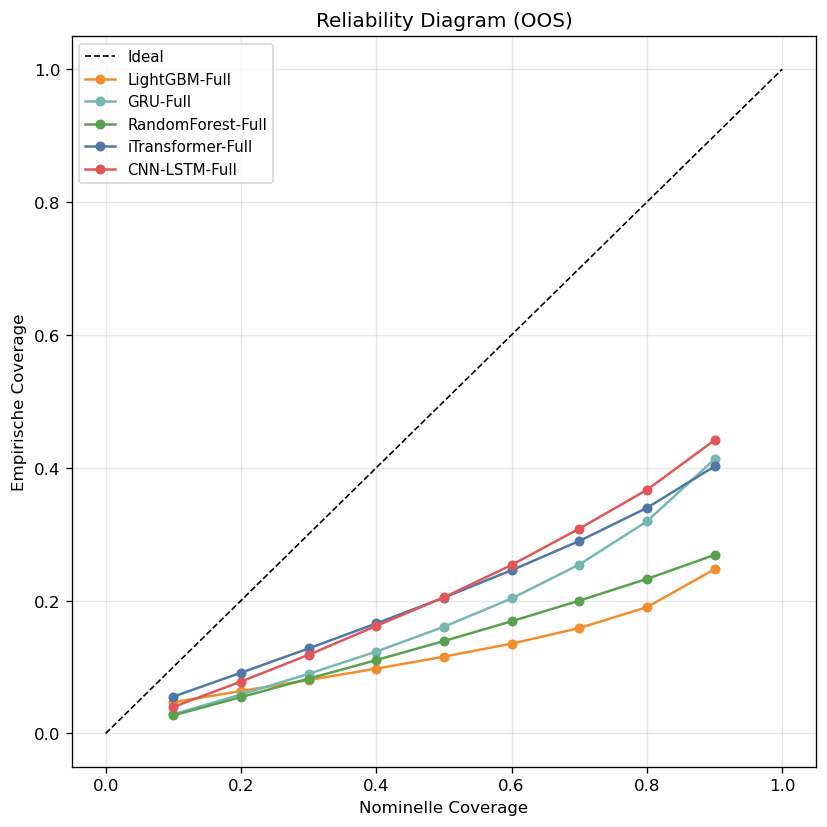

In [103]:
def _reliability(q10, q90, y, n=9):
    mid  = (q10 + q90) / 2.0
    half = (q90 - q10) / 2.0
    nom, emp = [], []
    for alpha in np.linspace(0.1, 0.9, n):
        lo = mid - alpha * half; hi = mid + alpha * half
        emp.append(float(((y >= lo) & (y <= hi)).mean()))
        nom.append(alpha)
    return nom, emp

_plot_list = [
    ('LightGBM-Full',     _lgb_q10,  _lgb_q90,  _lgb_y),
    ('GRU-Full',          _gru_q10,  _gru_q90,  _gru_oos_y),
    ('RandomForest-Full', _rf_q10,   _rf_q90,   _rf_y),
    ('iTransformer-Full', _itr_q10,  _itr_q90,  _itr_oos_y),
    ('CNN-LSTM-Full',     _cnn_q10,  _cnn_q90,  _cnn_oos_y),
]

_fig, _ax = plt.subplots(figsize=(7, 7))
_ax.plot([0,1],[0,1],'k--',lw=1,label='Ideal')
for _mn, _q10, _q90, _y in _plot_list:
    if any(x is None for x in [_q10, _q90, _y]): continue
    if len(_q10) != len(_y):
        print(f'  {_mn}: Array-Längen passen nicht ({len(_q10)} vs {len(_y)}) – übersprungen')
        continue
    _nom, _emp = _reliability(_q10, _q90, _y)
    _ax.plot(_nom, _emp, 'o-', color=PALETTE[_mn], label=_mn, ms=5)
_ax.set_xlabel('Nominelle Coverage'); _ax.set_ylabel('Empirische Coverage')
_ax.set_title('Reliability Diagram (OOS)')
_ax.legend(fontsize=9); _ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'full_reliability.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Vorhersage – alle Modelle im Vergleich (36h)

Für denselben 36-Stunden-Zeitraum (144 Timesteps à 15 min): Vorhersage aller Modelle
vs. tatsächliche Produktion auf einem OOS-Spot. DL-Modelle: stride=1 Inference (gecacht).
RF und LightGBM: direkt auf denselben Spot-Features.

Cache geladen: ['GRU-Full', 'iTransformer-Full', 'CNN-LSTM-Full', 'RandomForest-Full', 'LightGBM-Full']


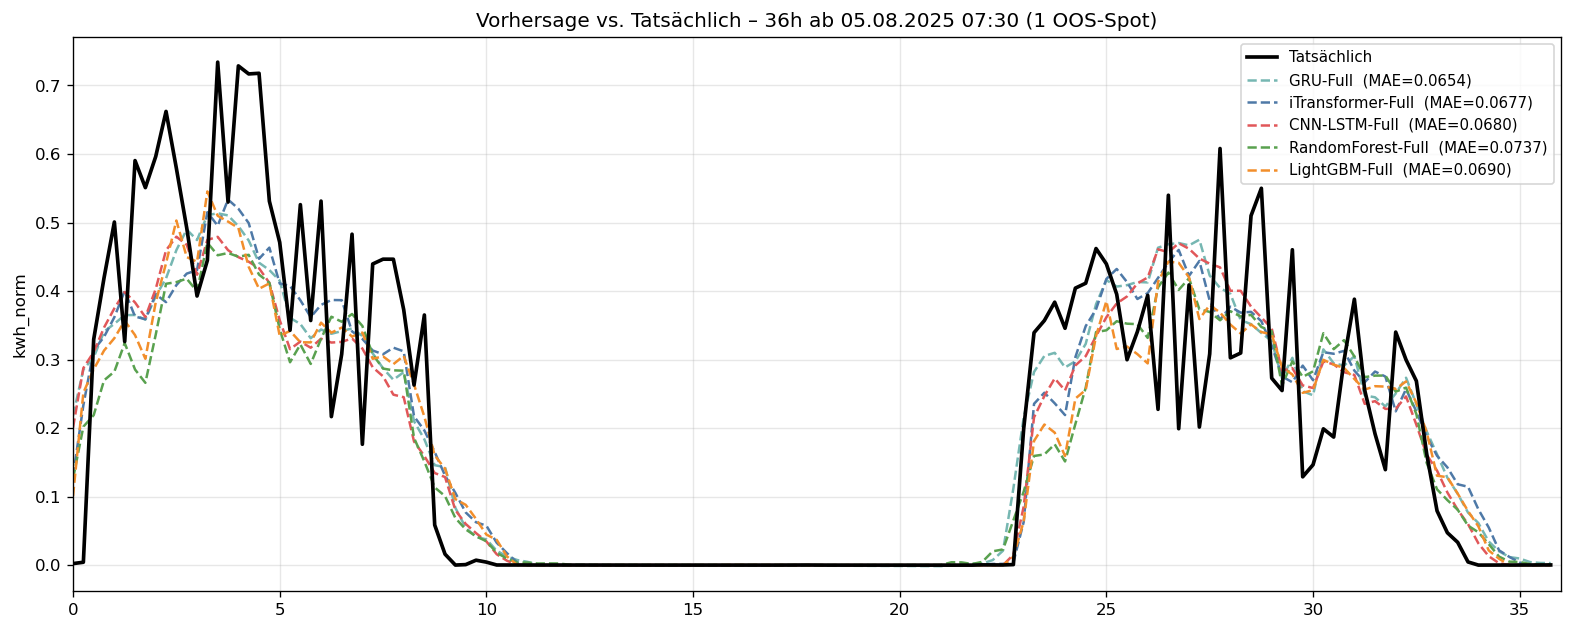

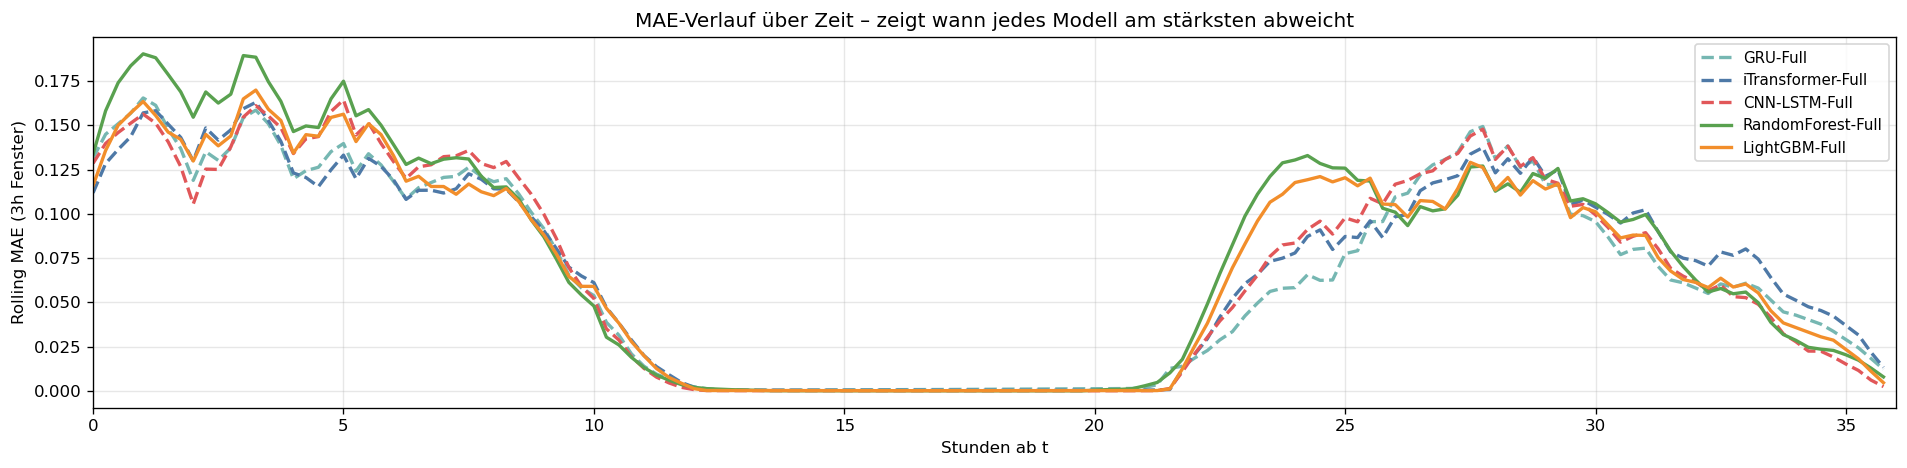

<Figure size 768x576 with 0 Axes>

In [104]:
import torch, torch.nn as nn, joblib, lightgbm as lgb
from sklearn.preprocessing import StandardScaler
import pyarrow.dataset as pads
import pyarrow.compute as papc
import gc

_N_STEPS = 144  # 36h
_dl_cache_path = RESULTS_DIR / 'dl_stride1_cache.npz'

# ── Modell-Definitionen ───────────────────────────────────────────────────────
class _GRUMod(nn.Module):
    def __init__(self, nf, hid, nl, dr):
        super().__init__()
        self.gru  = nn.GRU(nf, hid, nl, batch_first=True, dropout=dr if nl>1 else 0.0)
        self.norm = nn.LayerNorm(hid)
        self.head = nn.Sequential(nn.Linear(hid,hid//2), nn.GELU(), nn.Dropout(dr), nn.Linear(hid//2,4))
    def forward(self, x): _, h = self.gru(x); return self.head(self.norm(h[-1]))

class _ITrLayer(nn.Module):
    def __init__(self, d, nh, dff, dr):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d, nh, dropout=dr, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d,dff), nn.GELU(), nn.Dropout(dr), nn.Linear(dff,d), nn.Dropout(dr))
        self.norm1 = nn.LayerNorm(d); self.norm2 = nn.LayerNorm(d)
    def forward(self, x):
        r=x; x,_=self.attn(x,x,x,need_weights=False); x=self.norm1(x+r); r=x
        return self.norm2(self.ff(x)+r)

class _ITrMod(nn.Module):
    def __init__(self, slen, nf, d, nh, nl, dff, dr):
        super().__init__()
        self.input_proj = nn.Linear(slen, d)
        self.layers = nn.ModuleList([_ITrLayer(d,nh,dff,dr) for _ in range(nl)])
        self.norm   = nn.LayerNorm(d)
        self.head   = nn.Sequential(nn.Linear(nf*d,d), nn.GELU(), nn.Dropout(dr), nn.Linear(d,4))
    def forward(self, x):
        x = self.input_proj(x.transpose(1,2))
        for _l in self.layers: x = _l(x)
        return self.head(self.norm(x).flatten(1))

class _CNNMod(nn.Module):
    def __init__(self, nf, ch, hid, nl, dr):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv1d(nf,ch,3,padding=1), nn.BatchNorm1d(ch), nn.ReLU())
        self.lstm = nn.LSTM(ch, hid, nl, batch_first=True, dropout=dr if nl>1 else 0.0)
        self.head = nn.Sequential(nn.Linear(hid,hid//2), nn.ReLU(), nn.Dropout(dr), nn.Linear(hid//2,4))
    def forward(self, x):
        x = self.conv(x.permute(0,2,1)).permute(0,2,1)
        _,(h,_) = self.lstm(x); return self.head(h[-1])

# ── Daten für 3 Spots laden (einmal, für alle Modelle) ───────────────────────
if _dl_cache_path.exists():
    _cache    = np.load(_dl_cache_path, allow_pickle=True)
    _dl_preds = dict(_cache['preds'].item())
    _dl_y     = _cache['y']
    _dl_ts    = pd.to_datetime(_cache['ts'])
    _X_sc     = _cache['X_sc'] if 'X_sc' in _cache.files else None
    print(f'Cache geladen: {list(_dl_preds.keys())}')
    # Fehlende Modelle nachberechnen falls nicht im Cache
    _MISSING = [m for m in ['RandomForest-Full','LightGBM-Full'] if m not in _dl_preds]
    if _MISSING:
        _oos_spots2 = pd.read_parquet(OOS_PATH)['spot_uuid'].tolist()[:3]
        _df2 = (pads.dataset(str(DATA_PATH))
                    .to_table(columns=FEATURES+['ts','spot_uuid','kwh_norm'],
                               filter=papc.field('spot_uuid').isin(_oos_spots2))
                    .to_pandas())
        _df2['ts'] = pd.to_datetime(_df2['ts'])
        _df2 = _df2.dropna(subset=['kwh_norm']).sort_values(['spot_uuid','ts']).reset_index(drop=True)
        _df2[FEATURES] = _df2[FEATURES].ffill().fillna(0.0)
        if 'RandomForest-Full' in _MISSING and (RF_DIR/'rf_model.pkl').exists():
            _rf_m = joblib.load(RF_DIR/'rf_model.pkl')
            _rf_s = joblib.load(RF_DIR/'rf_scaler.pkl') if (RF_DIR/'rf_scaler.pkl').exists() else StandardScaler().fit(_df2[FEATURES])
            _dl_preds['RandomForest-Full'] = np.maximum(0, _rf_m.predict(_rf_s.transform(_df2[FEATURES].values.astype(np.float32))).astype(np.float32))
            print('  RandomForest-Full nachberechnet'); del _rf_m; gc.collect()
        if 'LightGBM-Full' in _MISSING and (LGB_DIR/'lgbm_point.txt').exists():
            _lgb_m = lgb.Booster(model_file=str(LGB_DIR/'lgbm_point.txt'))
            _dl_preds['LightGBM-Full'] = np.maximum(0, _lgb_m.predict(_df2[FEATURES].values.astype(np.float32)).astype(np.float32))
            print('  LightGBM-Full nachberechnet'); del _lgb_m; gc.collect()
        del _df2; gc.collect()
else:
    _oos_spots = pd.read_parquet(OOS_PATH)['spot_uuid'].tolist()[:3]
    _df_hz = (pads.dataset(str(DATA_PATH))
                  .to_table(columns=FEATURES+['ts','spot_uuid','kwh_norm'],
                             filter=papc.field('spot_uuid').isin(_oos_spots))
                  .to_pandas())
    _df_hz['ts'] = pd.to_datetime(_df_hz['ts'])
    _df_hz = _df_hz.dropna(subset=['kwh_norm']).sort_values(['spot_uuid','ts']).reset_index(drop=True)
    _df_hz[FEATURES] = _df_hz[FEATURES].ffill().fillna(0.0)
    _sc   = StandardScaler()
    _X_sc = _sc.fit_transform(_df_hz[FEATURES].values.astype(np.float32))
    _dl_y  = _df_hz['kwh_norm'].values.astype(np.float32)
    _dl_ts = _df_hz['ts']
    _segs  = []
    _p = 0
    for _, _g in _df_hz.groupby('spot_uuid', observed=True):
        _segs.append((_p, len(_g))); _p += len(_g)

    _dl_preds = {}

    # DL Modelle
    for _mn, _dir, _jf, _ptf, _CLS in [
        ('GRU-Full',          GRU_DIR, 'gru_results.json',          'gru_model.pt',          'GRU'),
        ('iTransformer-Full', ITR_DIR, 'itransformer_results.json', 'itransformer_model.pt', 'ITR'),
        ('CNN-LSTM-Full',     CNN_DIR, 'cnnlstm_results.json',      'cnnlstm_model.pt',      'CNN'),
    ]:
        if not (_dir/_jf).exists() or not (_dir/_ptf).exists(): print(f'  [{_mn}] fehlt'); continue
        with open(_dir/_jf) as _f: _bp = json.load(_f)['best_params']
        _slen = _bp['slen']
        if _CLS=='GRU':   _mdl = _GRUMod(N_FEAT, _bp['hid'], _bp['n_layers'], _bp['dropout'])
        elif _CLS=='ITR': _mdl = _ITrMod(_slen, N_FEAT, _bp['d_model'], _bp['n_heads'], _bp['n_layers'], _bp['d_ff'], _bp['dropout'])
        else:             _mdl = _CNNMod(N_FEAT, _bp['cnn_ch'], _bp['hid'], _bp['n_layers'], _bp['dropout'])
        _mdl.load_state_dict(torch.load(_dir/_ptf, map_location='cpu', weights_only=True))
        _mdl.eval()
        _preds = np.full(len(_df_hz), np.nan, dtype=np.float32)
        _p = 0
        for _sp_start, _sp_n in _segs:
            if _sp_n < _slen: _p += _sp_n; continue
            with torch.no_grad():
                for _i in range(_slen-1, _sp_n):
                    _out = _mdl(torch.tensor(_X_sc[_p+_i-_slen+1:_p+_i+1]).unsqueeze(0))
                    _preds[_p+_i] = float(_out[0,0])
            _p += _sp_n
        _dl_preds[_mn] = _preds
        print(f'  {_mn} fertig'); del _mdl; gc.collect()

    # RF
    _rf_pkl = RF_DIR / 'rf_model.pkl'
    _rf_sc_pkl = RF_DIR / 'rf_scaler.pkl'
    if _rf_pkl.exists():
        _rf_mdl = joblib.load(_rf_pkl)
        _rf_sc  = joblib.load(_rf_sc_pkl) if _rf_sc_pkl.exists() else _sc
        _X_rf   = _rf_sc.transform(_df_hz[FEATURES].values.astype(np.float32))
        _dl_preds['RandomForest-Full'] = np.maximum(0, _rf_mdl.predict(_X_rf).astype(np.float32))
        print('  RandomForest-Full fertig'); del _rf_mdl; gc.collect()

    # LightGBM
    _lgb_txt = LGB_DIR / 'lgbm_point.txt'
    if _lgb_txt.exists():
        _lgb_mdl = lgb.Booster(model_file=str(_lgb_txt))
        _dl_preds['LightGBM-Full'] = np.maximum(0, _lgb_mdl.predict(_df_hz[FEATURES].values.astype(np.float32)).astype(np.float32))
        print('  LightGBM-Full fertig'); del _lgb_mdl; gc.collect()

    np.savez(_dl_cache_path, preds=np.array(_dl_preds, dtype=object),
             y=_dl_y, ts=np.array(_dl_ts), X_sc=_X_sc)
    print('Cache gespeichert.')

# ── Spot-Grenzen bestimmen + bestes Fenster in Spot 0 ────────────────────────
_ts_pd = pd.to_datetime(_dl_ts)
_gaps  = np.where(np.diff(_ts_pd.astype(np.int64)) > pd.Timedelta('2h').value)[0] + 1
_spot_ends = list(_gaps) + [len(_ts_pd)]
_spot0_end = _spot_ends[0]

_best_i, _best_score = 0, -1.0
for _i in range(0, _spot0_end - _N_STEPS, 24):
    _c = _dl_y[_i:_i+_N_STEPS]
    _s = float(_c.max()*0.6 + _c.mean()*0.4)
    if _c.max() > 0.4 and _c.mean() > 0.08 and _s > _best_score:
        _best_score = _s; _best_i = _i

_sl  = slice(_best_i, _best_i + _N_STEPS)
_t0  = _ts_pd[_best_i]
_x_h = np.arange(_N_STEPS) * 0.25

# ── Plot ─────────────────────────────────────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(16, 6))
_ax.plot(_x_h, _dl_y[_sl], 'k-', lw=2.2, label='Tatsächlich', zorder=5)
for _mn, _preds in _dl_preds.items():
    _v = ~np.isnan(_preds[_sl])
    if _v.sum() > 10:
        _mae_win = float(np.abs(_preds[_sl][_v] - _dl_y[_sl][_v]).mean())
        _ax.plot(_x_h[_v], _preds[_sl][_v],
                 color=PALETTE.get(_mn,'#888'), lw=1.5, ls='--',
                 label=f'{_mn}  (MAE={_mae_win:.4f})')
_ax.set_ylabel('kwh_norm')
_ax.set_title(f'Vorhersage vs. Tatsächlich – 36h ab {_t0.strftime("%d.%m.%Y %H:%M")} (1 OOS-Spot)')
_ax.legend(fontsize=9); _ax.grid(alpha=0.3); _ax.set_xlim(0, _N_STEPS*0.25)

# ── Rolling MAE (Fenster = 12 Timesteps = 3h) ────────────────────────────────
_fig2, _ax2 = plt.subplots(figsize=(16, 4))
_roll = 12  # 3h Fenster
for _mn, _preds in _dl_preds.items():
    _v = ~np.isnan(_preds[_sl])
    if _v.sum() < _roll: continue
    _err = np.abs(_preds[_sl] - _dl_y[_sl])  # absoluter Fehler pro Timestep
    _err[~_v] = np.nan
    # Rolling mean über 3h
    _rolled = pd.Series(_err).rolling(_roll, center=True, min_periods=4).mean().values
    _ax2.plot(_x_h, _rolled, color=PALETTE.get(_mn,'#888'), lw=2,
              label=_mn, ls='-' if _mn in ['LightGBM-Full','RandomForest-Full'] else '--')
_ax2.set_xlabel('Stunden ab t')
_ax2.set_ylabel('Rolling MAE (3h Fenster)')
_ax2.set_title('MAE-Verlauf über Zeit – zeigt wann jedes Modell am stärksten abweicht')
_ax2.legend(fontsize=9); _ax2.grid(alpha=0.3); _ax2.set_xlim(0, _N_STEPS*0.25)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'full_comparison_36h.png', dpi=150, bbox_inches='tight')
plt.show()
_fig2.tight_layout()
plt.savefig(RESULTS_DIR / 'full_rolling_mae.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Vorhersage vs. Tatsächlich (48h-Fenster)

Für jedes Modell separat: Vorhersage vs. tatsächliche Produktion über 48 Stunden (192 Timesteps).
Nutzt denselben stride=1 Cache wie Sektion 2 — korrekte 15-min Predictions für alle Modelle.

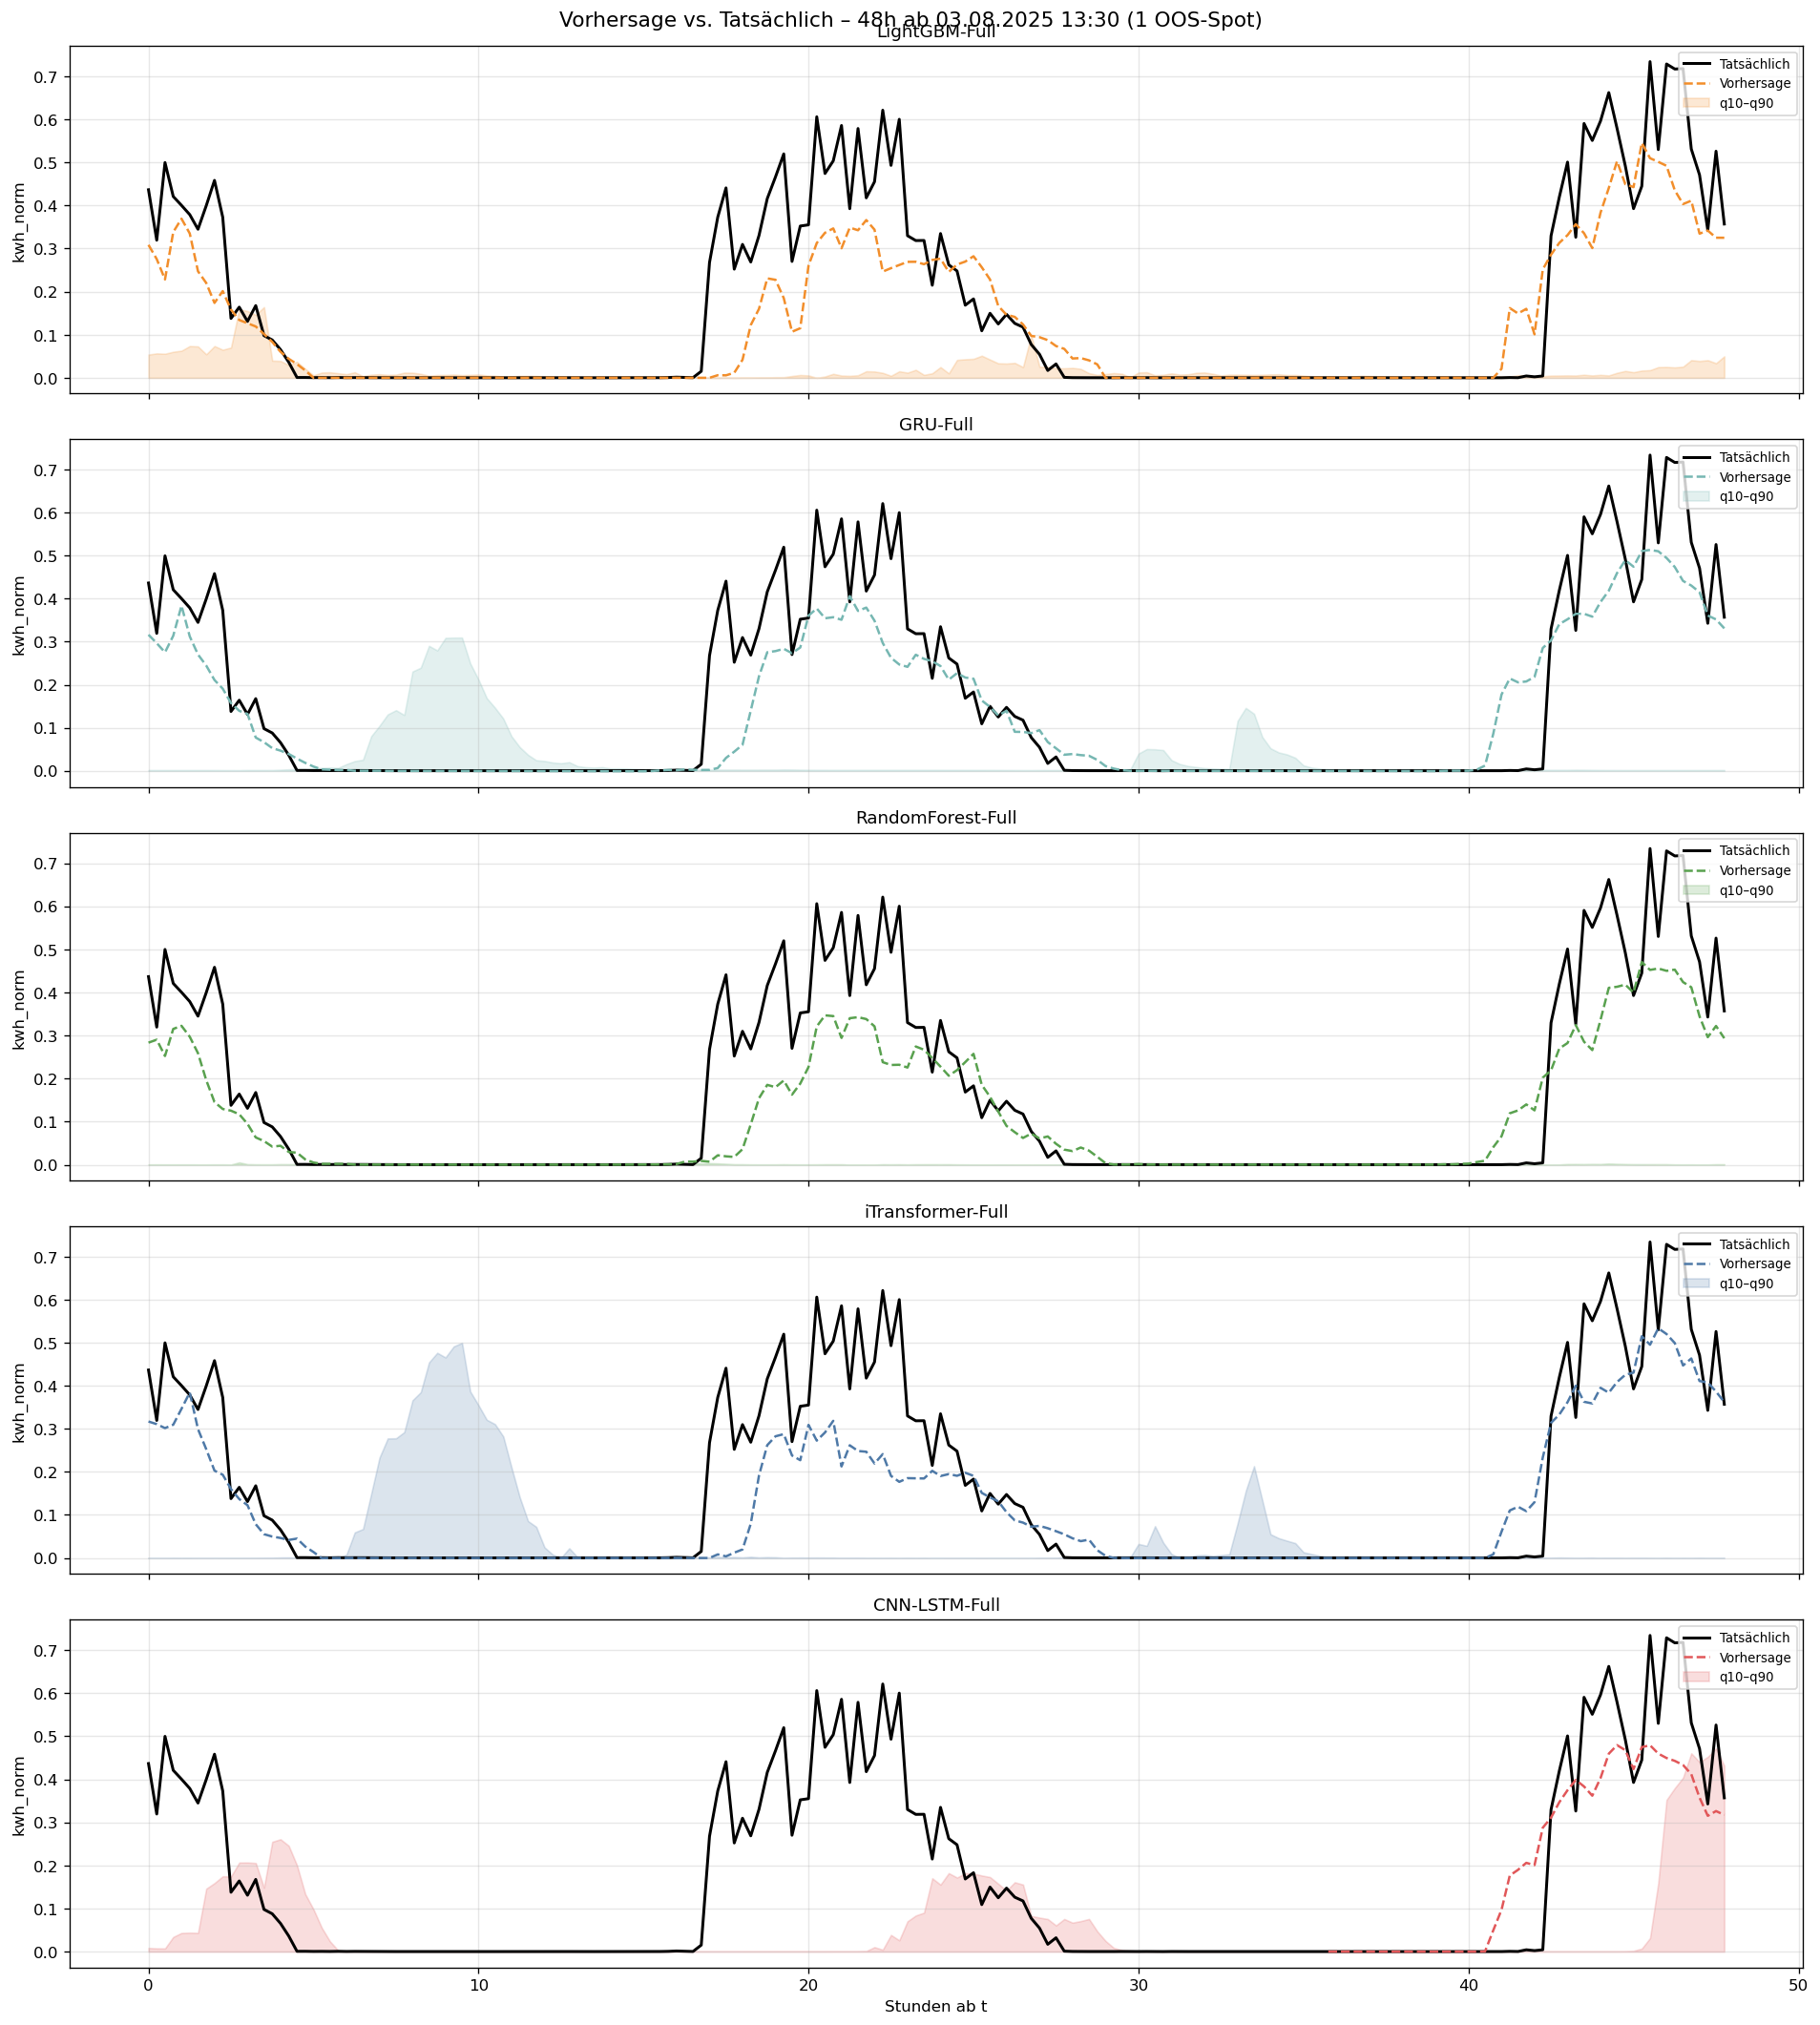

In [105]:
_W48 = 192  # 48h

# Spot-Grenzen in Cache-Daten bestimmen
_ts48 = pd.to_datetime(_dl_ts)
_gaps48 = np.where(np.diff(_ts48.astype(np.int64)) > pd.Timedelta('2h').value)[0] + 1
_spot0_end48 = int(_gaps48[0]) if len(_gaps48) > 0 else len(_dl_y)

# Bestes 48h-Fenster in Spot 0 suchen
_best48, _score48 = 0, -1.0
for _i in range(0, _spot0_end48 - _W48, 24):
    _c = _dl_y[_i:_i+_W48]
    _s = float(_c.max()*0.6 + _c.mean()*0.4)
    if _c.max() > 0.4 and _c.mean() > 0.08 and _s > _score48:
        _score48 = _s; _best48 = _i

_sl48 = slice(_best48, _best48 + _W48)
_x48  = np.arange(_W48) * 0.25  # Stunden
_t48  = _ts48[_best48]

_fig48, _axes48 = plt.subplots(5, 1, figsize=(16, 18), sharex=True)
for _ax48, _mn in zip(_axes48, MODELS):
    _preds48 = _dl_preds.get(_mn)
    if _preds48 is None:
        _ax48.set_title(f'{_mn} – nicht verfügbar'); continue
    _v = ~np.isnan(_preds48[_sl48])
    # q10/q90 aus OOS-Arrays
    _q10_map = {'LightGBM-Full':_lgb_q10,'GRU-Full':_gru_q10,
                'RandomForest-Full':_rf_q10,'iTransformer-Full':_itr_q10,'CNN-LSTM-Full':_cnn_q10}
    _q90_map = {'LightGBM-Full':_lgb_q90,'GRU-Full':_gru_q90,
                'RandomForest-Full':_rf_q90,'iTransformer-Full':_itr_q90,'CNN-LSTM-Full':_cnn_q90}
    _q10_arr = _q10_map.get(_mn); _q90_arr = _q90_map.get(_mn)
    _ax48.plot(_x48, _dl_y[_sl48], 'k-', lw=1.8, label='Tatsächlich')
    _ax48.plot(_x48[_v], _preds48[_sl48][_v],
               color=PALETTE.get(_mn,'#888'), lw=1.5, ls='--', label='Vorhersage')
    if _q10_arr is not None and _q90_arr is not None and len(_q10_arr) > _best48+_W48:
        _ax48.fill_between(_x48, _q10_arr[_sl48], _q90_arr[_sl48],
                           alpha=0.2, color=PALETTE.get(_mn,'#888'), label='q10–q90')
    _ax48.set_title(_mn, fontsize=11)
    _ax48.set_ylabel('kwh_norm')
    _ax48.legend(fontsize=8, loc='upper right')
    _ax48.grid(alpha=0.3)
_axes48[-1].set_xlabel('Stunden ab t')
plt.suptitle(f'Vorhersage vs. Tatsächlich – 48h ab {_t48.strftime("%d.%m.%Y %H:%M")} (1 OOS-Spot)',
             fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'full_interval_example.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Feature Importance

- **LightGBM & RandomForest**: Gain- bzw. Gini-Importance (aus dem Modell)
- **GRU, iTransformer, CNN-LSTM**: Permutation Importance (Δ MAE bei zufälligem Shuffeln)

Top-20 Features pro Modell.

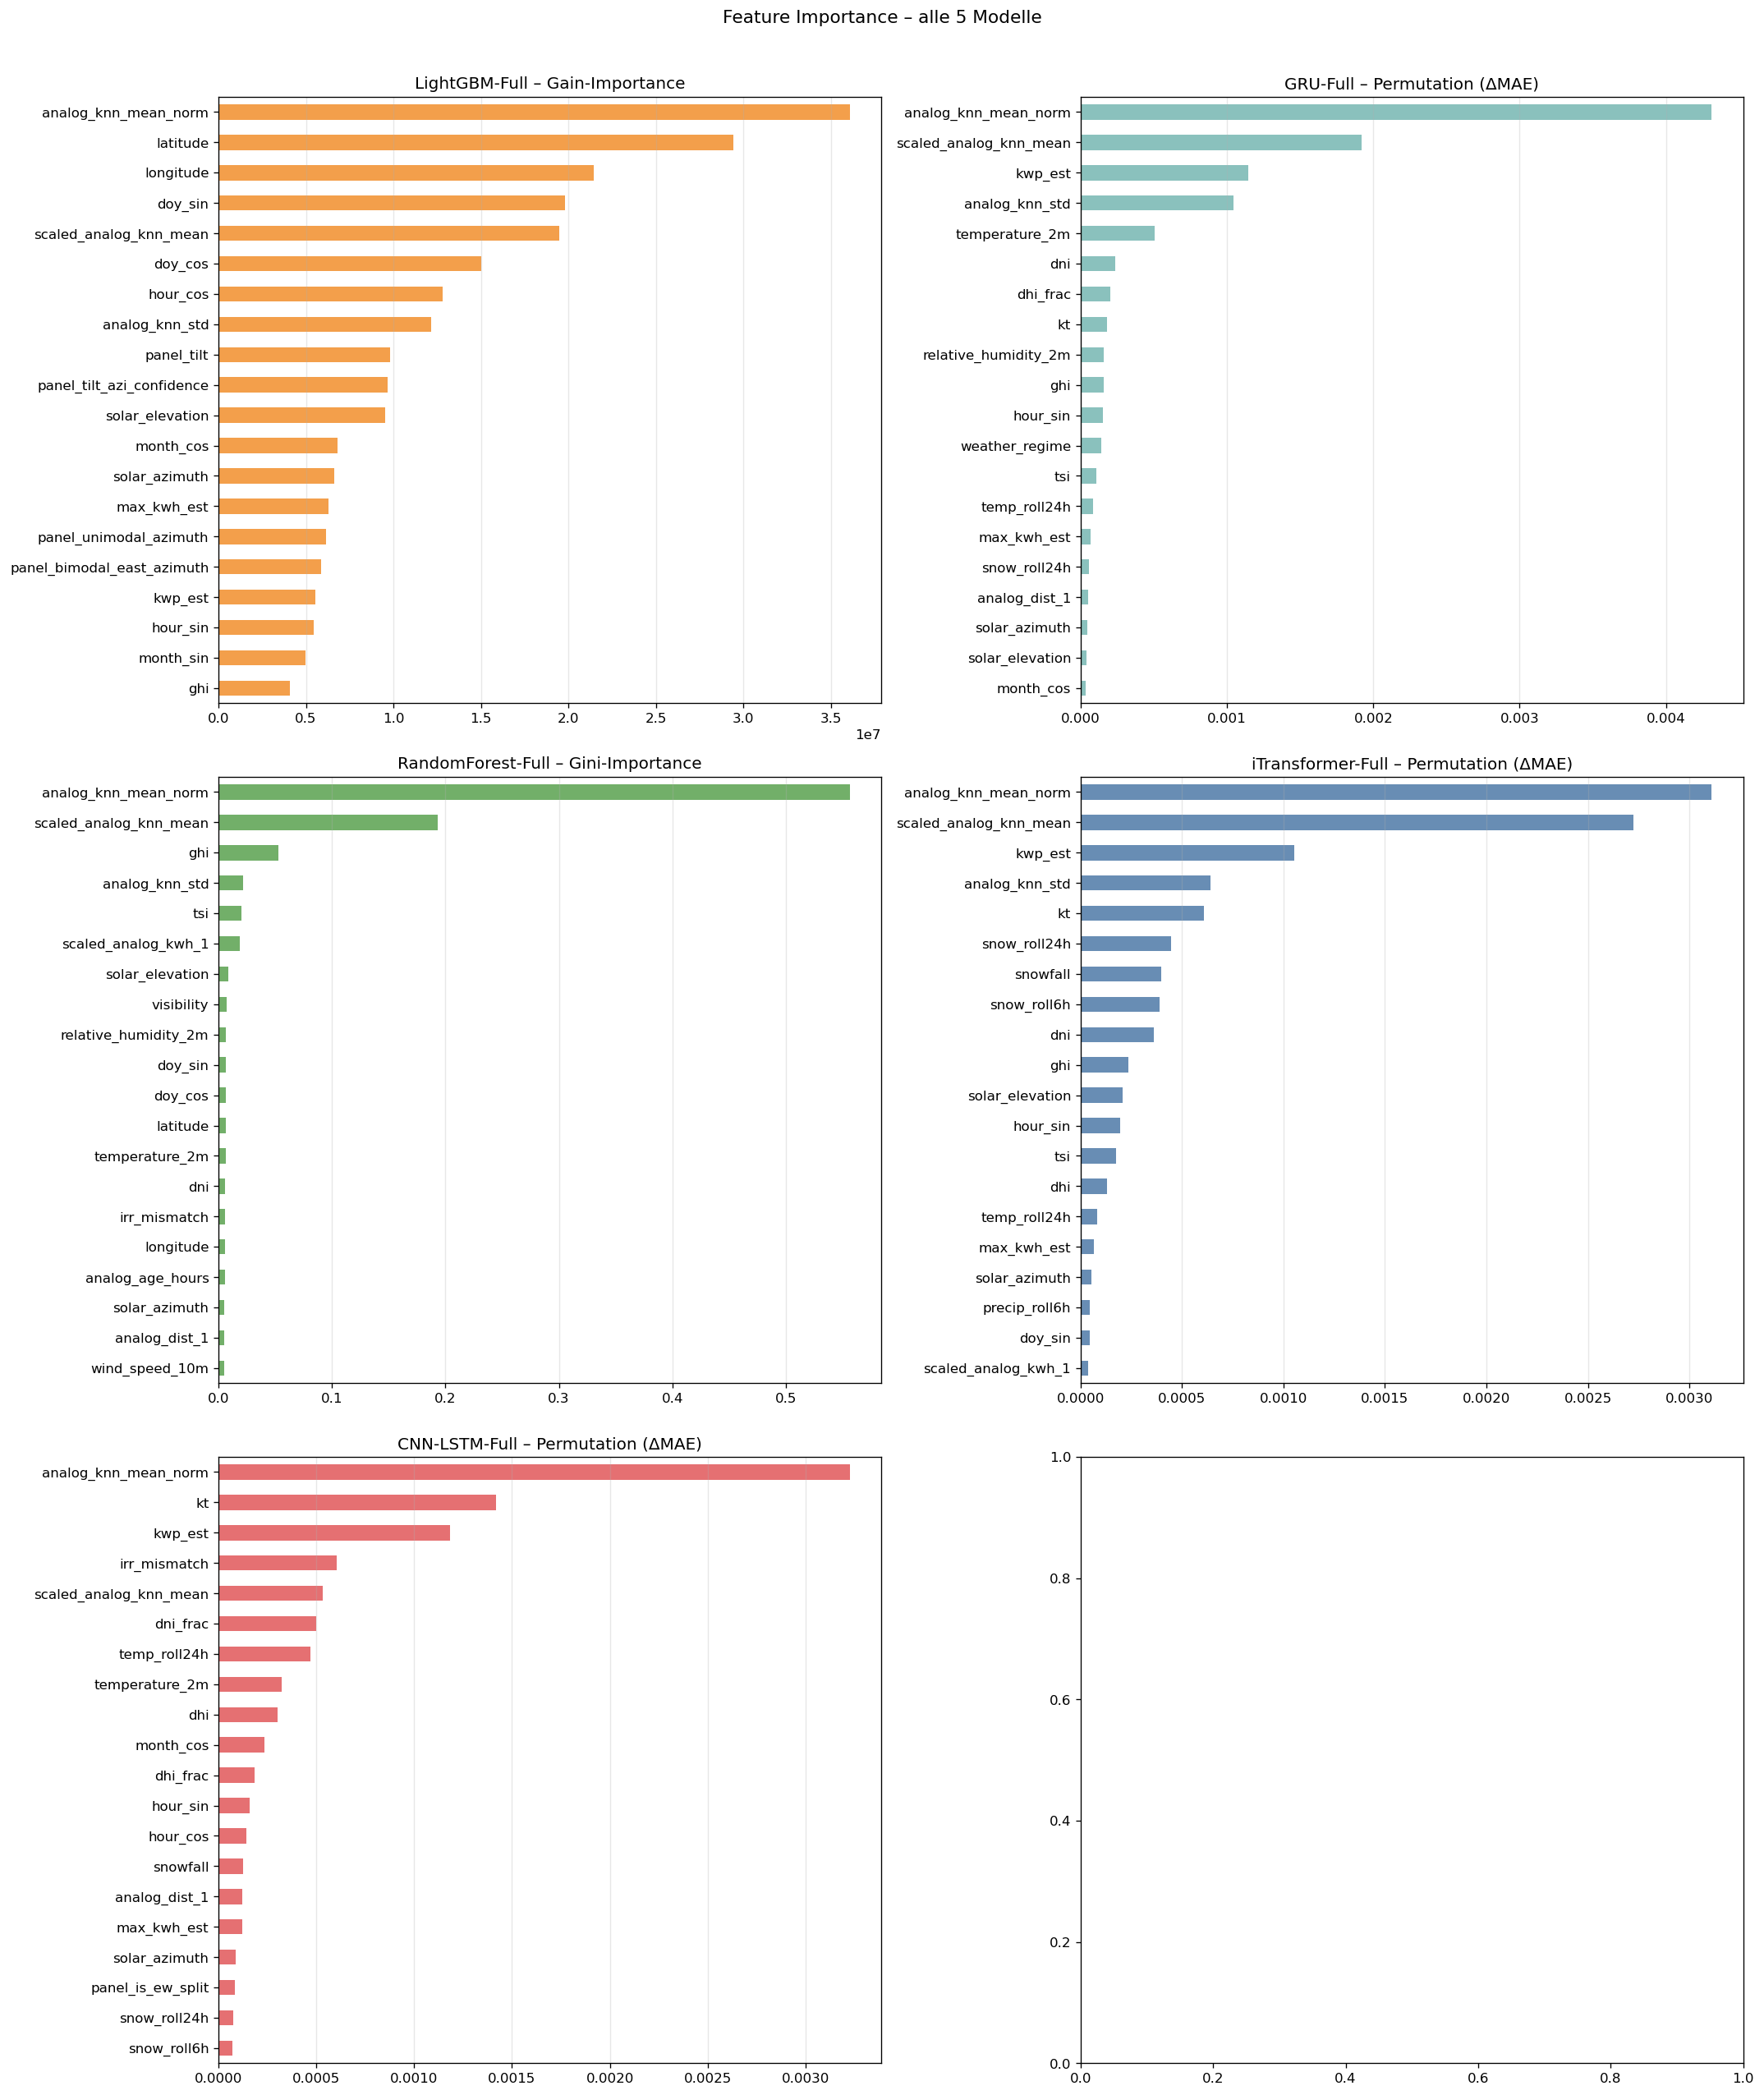

In [106]:
_fi_data = {}
for _mn, _key in [('LightGBM-Full','LightGBM-Full'),('RandomForest-Full','RandomForest-Full')]:
    if _mn in _res_json and 'feature_importance' in _res_json[_mn]:
        _fi_data[_mn] = _res_json[_mn]['feature_importance']
for _mn in ['GRU-Full','iTransformer-Full','CNN-LSTM-Full']:
    if _mn in _res_json and 'permutation_importance' in _res_json[_mn]:
        _fi_data[_mn] = _res_json[_mn]['permutation_importance']

_labels = {'LightGBM-Full':'Gain-Importance','RandomForest-Full':'Gini-Importance',
           'GRU-Full':'Permutation (ΔMAE)','iTransformer-Full':'Permutation (ΔMAE)',
           'CNN-LSTM-Full':'Permutation (ΔMAE)'}

_fig_fi, _axes_fi = plt.subplots(3, 2, figsize=(18, 21))
for _ax_fi, _mn in zip(_axes_fi.flatten(), MODELS):
    if _mn not in _fi_data:
        _ax_fi.set_title(f'{_mn} – Daten fehlen'); continue
    _df_fi = pd.Series(_fi_data[_mn]).sort_values(ascending=False).head(20).sort_values()
    _df_fi.plot(kind='barh', ax=_ax_fi, color=PALETTE.get(_mn,'#888'), alpha=0.85)
    _ax_fi.set_title(f'{_mn} – {_labels.get(_mn,"Importance")}')
    _ax_fi.grid(axis='x', alpha=0.3)
plt.suptitle('Feature Importance – alle 5 Modelle', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'full_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Inferenzzeit & Stromkosten

Gemessen: 144 Predictions pro Durchlauf, 50 Wiederholungen.
Preisformel: `Kosten = (t_ms / 144) × 1_000_000 / 3_600_000 × 0.065 kW × 0.37 EUR/kWh`
(65 W CPU, 37 ct/kWh, 1 Million Vorhersagen als Referenz)

LightGBM-Full:     13.38 ± 3.69 ms


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


RandomForest-Full: 13.57 ± 0.65 ms
GRU-Full:          76.81 ± 4.32 ms
CNN-LSTM-Full:     206.45 ± 7.09 ms
iTransformer-Full: 7.91 ± 0.38 ms


,Modell,Typ,Inf_ms,Std_ms,µs/Sample,EUR/1M Pred,n_params
0,LightGBM-Full,tree,13.38,3.69,92.92,0.0006,–
1,RandomForest-Full,tree,13.57,0.65,94.26,0.0006,80
2,GRU-Full,DL,76.81,4.32,533.40,0.0036,175044
3,CNN-LSTM-Full,DL,206.45,7.09,1433.65,0.0096,72864
4,iTransformer-Full,DL,7.91,0.38,54.92,0.0004,842948


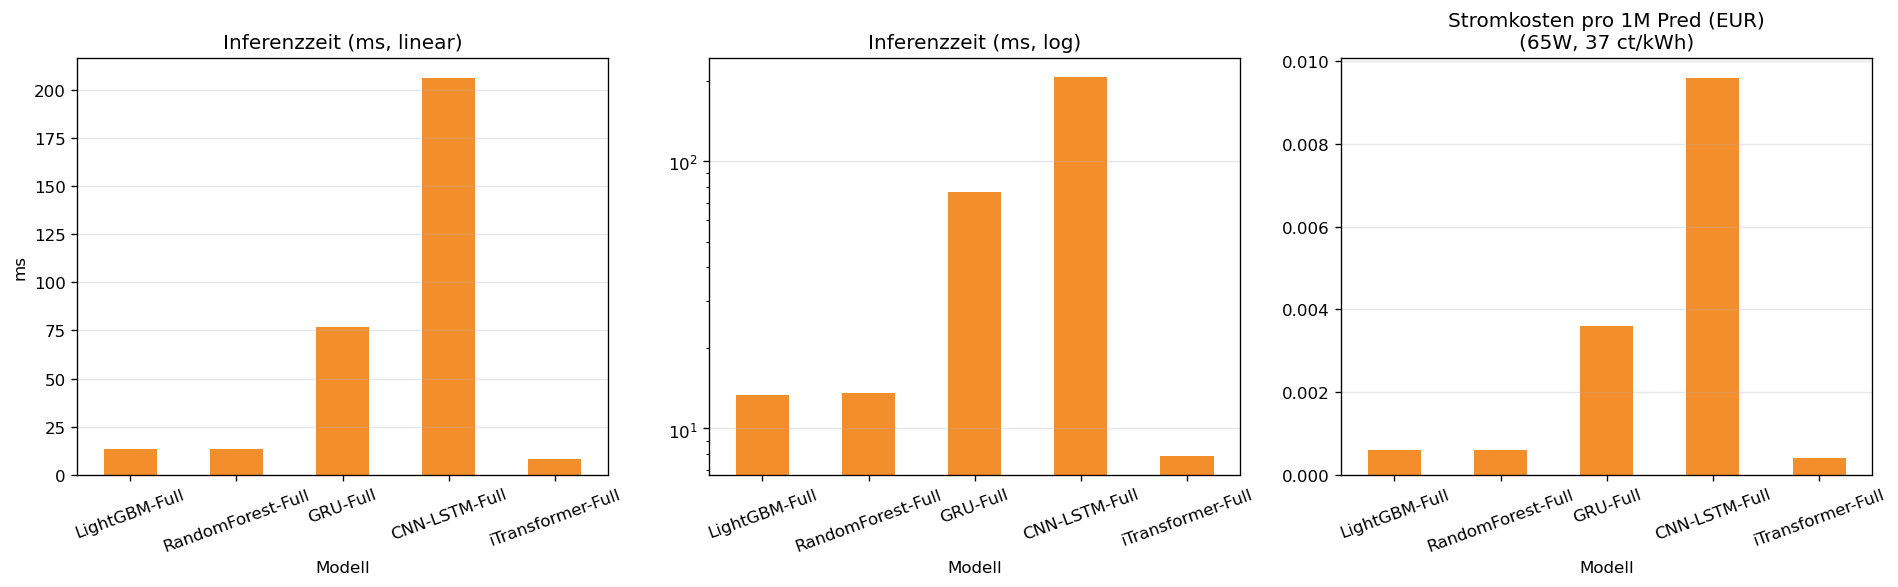

In [107]:
# _CNNMod / _GRUMod / _ITrMod aus Cell 16 (Horizont) bereits im Kernel geladen

import time, gc, joblib
import torch, torch.nn as nn
import lightgbm as lgb
import numpy as np

_BATCH      = 144
_N_REPS     = 50
_N_PRED_REF = 1_000_000
_CPU_W      = 65
_PRICE_EUR  = 0.37

def _cost_per_M(inf_ms):
    h = (inf_ms / _BATCH) * _N_PRED_REF / 3_600_000
    return h * (_CPU_W / 1000) * _PRICE_EUR

def _measure(fn, n=_N_REPS):
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        ts.append((time.perf_counter() - t0) * 1000)
    ts = ts[5:]  # Warm-up verwerfen
    return float(np.mean(ts)), float(np.std(ts))

# Dummy-Eingaben
_X_dummy = np.random.randn(_BATCH, N_FEAT).astype(np.float32)
_X_dummy_ts = torch.tensor(np.random.randn(_BATCH, 168, N_FEAT).astype(np.float32))

_rows = []

# ── LightGBM ─────────────────────────────────────────────────────────────────
_lgb_pt_file = LGB_DIR / 'lgbm_point.txt'
if _lgb_pt_file.exists():
    _lgb_mdl = lgb.Booster(model_file=str(_lgb_pt_file))
    _ms, _sd = _measure(lambda: _lgb_mdl.predict(_X_dummy))
    _rows.append({'Modell': 'LightGBM-Full', 'Inf_ms': _ms, 'Std_ms': _sd,
                  'Typ': 'tree', 'n_params': _res_json.get('LightGBM-Full', {}).get('n_estimators', '–')})
    print(f'LightGBM-Full:     {_ms:.2f} ± {_sd:.2f} ms')
    del _lgb_mdl; gc.collect()
else:
    print(f'LightGBM: lgbm_point.txt nicht gefunden')

# ── RandomForest ──────────────────────────────────────────────────────────────
_rf_pkl = RF_DIR / 'rf_model.pkl'
if _rf_pkl.exists():
    _rf_mdl = joblib.load(_rf_pkl)
    _ms, _sd = _measure(lambda: _rf_mdl.predict(_X_dummy))
    _rows.append({'Modell': 'RandomForest-Full', 'Inf_ms': _ms, 'Std_ms': _sd,
                  'Typ': 'tree', 'n_params': getattr(_rf_mdl, 'n_estimators', '–')})
    print(f'RandomForest-Full: {_ms:.2f} ± {_sd:.2f} ms')
    del _rf_mdl; gc.collect()
else:
    print(f'RandomForest: rf_model.pkl nicht gefunden')

# ── GRU ───────────────────────────────────────────────────────────────────────
_gru_pt_file = GRU_DIR / 'gru_model.pt'
if _gru_pt_file.exists() and 'GRU-Full' in _res_json:
    _bp = _res_json['GRU-Full']['best_params']
    _gru_mdl = _GRUMod(N_FEAT, _bp['hid'], _bp['n_layers'], _bp['dropout'])
    _gru_mdl.load_state_dict(torch.load(_gru_pt_file, map_location='cpu', weights_only=True))
    _gru_mdl.eval()
    _X_gru = torch.tensor(np.random.randn(_BATCH, _bp['slen'], N_FEAT).astype(np.float32))
    with torch.no_grad():
        _ms, _sd = _measure(lambda: _gru_mdl(_X_gru))
    _rows.append({'Modell': 'GRU-Full', 'Inf_ms': _ms, 'Std_ms': _sd,
                  'Typ': 'DL', 'n_params': _res_json['GRU-Full'].get('n_params', '–')})
    print(f'GRU-Full:          {_ms:.2f} ± {_sd:.2f} ms')
    del _gru_mdl; gc.collect()
else:
    print('GRU: Dateien fehlen')

# ── CNN-LSTM ──────────────────────────────────────────────────────────────────
_cnn_pt_file = CNN_DIR / 'cnnlstm_model.pt'
if _cnn_pt_file.exists() and 'CNN-LSTM-Full' in _res_json:
    _bp = _res_json['CNN-LSTM-Full']['best_params']
    _cnn_mdl = _CNNMod(N_FEAT, _bp['cnn_ch'], _bp['hid'], _bp['n_layers'], _bp['dropout'])
    _cnn_mdl.load_state_dict(torch.load(_cnn_pt_file, map_location='cpu', weights_only=True))
    _cnn_mdl.eval()
    _X_cnn = torch.tensor(np.random.randn(_BATCH, _bp['slen'], N_FEAT).astype(np.float32))
    with torch.no_grad():
        _ms, _sd = _measure(lambda: _cnn_mdl(_X_cnn))
    _rows.append({'Modell': 'CNN-LSTM-Full', 'Inf_ms': _ms, 'Std_ms': _sd,
                  'Typ': 'DL', 'n_params': _res_json['CNN-LSTM-Full'].get('n_params', '–')})
    print(f'CNN-LSTM-Full:     {_ms:.2f} ± {_sd:.2f} ms')
    del _cnn_mdl; gc.collect()
else:
    print('CNN-LSTM: Dateien fehlen')

# ── iTransformer ─────────────────────────────────────────────────────────────
_itr_pt_file = ITR_DIR / 'itransformer_model.pt'
if _itr_pt_file.exists() and 'iTransformer-Full' in _res_json:
    _bp = _res_json['iTransformer-Full']['best_params']
    _itr_mdl = _ITrMod(_bp['slen'], N_FEAT, _bp['d_model'], _bp['n_heads'],
                        _bp['n_layers'], _bp['d_ff'], _bp['dropout'])
    _itr_mdl.load_state_dict(torch.load(_itr_pt_file, map_location='cpu', weights_only=True))
    _itr_mdl.eval()
    _X_itr = torch.tensor(np.random.randn(_BATCH, _bp['slen'], N_FEAT).astype(np.float32))
    with torch.no_grad():
        _ms, _sd = _measure(lambda: _itr_mdl(_X_itr))
    _rows.append({'Modell': 'iTransformer-Full', 'Inf_ms': _ms, 'Std_ms': _sd,
                  'Typ': 'DL', 'n_params': _res_json['iTransformer-Full'].get('n_params', '–')})
    print(f'iTransformer-Full: {_ms:.2f} ± {_sd:.2f} ms')
    del _itr_mdl; gc.collect()
else:
    print('iTransformer: Dateien fehlen')

# ── Tabelle ───────────────────────────────────────────────────────────────────
if _rows:
    _df_inf = pd.DataFrame(_rows)
    _df_inf['µs/Sample']    = (_df_inf['Inf_ms'] / _BATCH * 1000).round(2)
    _df_inf['EUR/1M Pred']  = _df_inf['Inf_ms'].apply(_cost_per_M).round(4)
    display(_df_inf[['Modell', 'Typ', 'Inf_ms', 'Std_ms', 'µs/Sample', 'EUR/1M Pred', 'n_params']]
             .style.format({'Inf_ms': '{:.2f}', 'Std_ms': '{:.2f}',
                            'µs/Sample': '{:.2f}', 'EUR/1M Pred': '{:.4f}'})
             .background_gradient(subset=['Inf_ms', 'EUR/1M Pred'], cmap='RdYlGn_r')
             .set_caption(f'Inferenzzeit ({_BATCH} Predictions, 65W CPU, 37 ct/kWh)'))

    # Plot: 3 Panels
    _fig, _axes = plt.subplots(1, 3, figsize=(16, 5))
    _colors = [PALETTE.get(r['Modell'], '#888') for _, r in _df_inf.iterrows()]
    _df_inf.set_index('Modell')[['Inf_ms']].plot(kind='bar', ax=_axes[0],
        color=_colors, legend=False, rot=20)
    _axes[0].set_title('Inferenzzeit (ms, linear)'); _axes[0].set_ylabel('ms')
    _axes[0].grid(axis='y', alpha=0.3)

    _df_inf.set_index('Modell')[['Inf_ms']].plot(kind='bar', ax=_axes[1],
        color=_colors, legend=False, rot=20)
    _axes[1].set_yscale('log'); _axes[1].set_title('Inferenzzeit (ms, log)')
    _axes[1].grid(axis='y', alpha=0.3)

    _df_inf.set_index('Modell')[['EUR/1M Pred']].plot(kind='bar', ax=_axes[2],
        color=_colors, legend=False, rot=20)
    _axes[2].set_title(f'Stromkosten pro 1M Pred (EUR)\n(65W, 37 ct/kWh)')
    _axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'full_inference_time.png', dpi=150, bbox_inches='tight')
    plt.show()
    _INF_RESULTS = {r['Modell']: r for r in _rows}
else:
    _INF_RESULTS = {}
    print('Keine Inferenzzeiten berechnet.')

## 8. UMBRA Batterieoptimierung

Alle 5 Full-Modelle werden durch den UMBRA Battery-Optimizer ausgewertet.
80 Spots (OOS + Training-Spots, seed=42). Ergebnisse werden in
`modelresults/umbra_full_results.json` persistiert.

In [108]:
import sys, gc, os, pickle, subprocess, tempfile
import random as _random
import json as _jmod
import lightgbm as lgb
import joblib as _jl
import pyarrow.dataset as pads
import pyarrow.compute as papc
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from datetime import time as dt_time

sys.path.insert(0, str(_BASE.parent.resolve()))
import importlib
try:
    import umbra_eval.umbra_exec_wrapper as _uw; importlib.reload(_uw)
except Exception as _re:
    print(f'Reload-Hinweis: {_re}')

_UMBRA_SAVE = RESULTS_DIR / 'umbra_full_results.json'
_UMBRA_SAVE.parent.mkdir(parents=True, exist_ok=True)
if _UMBRA_SAVE.exists():
    with open(_UMBRA_SAVE) as _f: _loaded = _jmod.load(_f)
    umbra_full_results = _loaded.get('models', {})
    umbra_full_gt_mean = _loaded.get('gt_mean', float('nan'))
    _saved_spots       = _loaded.get('umbra_spots', [])
    print(f'Geladen: {list(umbra_full_results.keys())}')
    print(f'GT: {umbra_full_gt_mean:.4f} kWh/Tag | {len(_saved_spots)} Spots')
else:
    umbra_full_results = {}; umbra_full_gt_mean = float('nan'); _saved_spots = []

def _save_umbra():
    with open(_UMBRA_SAVE, 'w') as _f:
        _jmod.dump({'gt_mean': umbra_full_gt_mean,
                    'umbra_spots': globals().get('_umbra_spots', _saved_spots),
                    'models': umbra_full_results}, _f, indent=2)
    print(f'    -> {_UMBRA_SAVE.name}')

_ALL_MODELS = ['LightGBM-Full', 'GRU-Full', 'RandomForest-Full', 'iTransformer-Full', 'CNN-LSTM-Full']
_MISSING    = [m for m in _ALL_MODELS if m not in umbra_full_results]
if not _MISSING:
    print('Alle Full-Modelle bereits ausgewertet.')
else:
    print(f'Ausstehend: {_MISSING}')

_REPO_PATH  = str(_BASE.parent.resolve())
_WORKER_SRC = (
    "import sys, pickle\n"
    "from datetime import time as dt_time\n"
    "sys.path.insert(0, sys.argv[5])\n"
    "from umbra_eval import get_umbra_battery_result_for_pv_input\n"
    "with open(sys.argv[1], 'rb') as f: _sh = pickle.load(f)\n"
    "with open(sys.argv[2], 'rb') as f: _pv = pickle.load(f)\n"
    "res = get_umbra_battery_result_for_pv_input(\n"
    "    uuids_to_loop=[sys.argv[3]], time_optimizer_runs=dt_time(22,0,0),\n"
    "    consumption=_sh['cons'], pv=_pv, da_prices=_sh['da'],\n"
    "    benchmark_day_threshold=_sh['threshold'], battery_meta=_sh['bat'],\n"
    ")\n"
    "with open(sys.argv[4], 'wb') as f: pickle.dump(res, f)\n"
)
_wf = tempfile.NamedTemporaryFile(suffix='.py', mode='w', delete=False)
_wf.write(_WORKER_SRC); _wf.close()
_worker_path = _wf.name

def _run_spot(spot, pv_df, shared_path):
    # Nur relevanten Spot picklen (spart Pickle-Zeit + RAM)
    if isinstance(pv_df.index, pd.MultiIndex):
        _spot_pv = pv_df
    else:
        _col = 'spot_uuid' if 'spot_uuid' in pv_df.columns else None
        _spot_pv = pv_df[pv_df[_col] == spot] if _col else pv_df
    _pv_f  = tempfile.NamedTemporaryFile(suffix='_pv.pkl',  delete=False)
    _res_f = tempfile.NamedTemporaryFile(suffix='_res.pkl', delete=False)
    _pv_f.close(); _res_f.close()
    with open(_pv_f.name, 'wb') as f: pickle.dump(_spot_pv, f)
    _proc = subprocess.Popen(
        [sys.executable, _worker_path,
         shared_path, _pv_f.name, spot, _res_f.name, _REPO_PATH],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    try:
        _proc.communicate(timeout=120)
        if _proc.returncode == 0 and os.path.getsize(_res_f.name) > 0:
            with open(_res_f.name, 'rb') as f: return pickle.load(f)
        return None
    except subprocess.TimeoutExpired:
        _proc.kill(); _proc.communicate()  # explizit killen
        return None
    finally:
        for _pp in [_pv_f.name, _res_f.name]:
            try: os.unlink(_pp)
            except: pass

def _run_all(pv_df, label=''):
    _results = []
    for _si, _sp in enumerate(_umbra_spots):
        _r = _run_spot(_sp, pv_df, _sh_path)
        if _r: _results.extend(_r)
        if (_si + 1) % 5 == 0 or _si == len(_umbra_spots)-1:
            print(f'    {label} [{_si+1}/{len(_umbra_spots)}] OK={len(_results)} Tage')
    return _results

def _store(name, results_list):
    global umbra_full_gt_mean
    if results_list:
        _df  = pd.DataFrame(results_list, columns=['start', 'spot_uuid', 'umbra_output'])
        _m   = float(_df['umbra_output'].mean())
        umbra_full_results[name] = {
            'mean': _m, 'delta': _m - umbra_full_gt_mean,
            'n_spots': int(_df['spot_uuid'].nunique()), 'n_days': len(_df)
        }
        print(f'    -> {_m:.4f} kWh/Tag (Δ={_m-umbra_full_gt_mean:+.4f})')
        _save_umbra()
    else:
        print(f'    Keine Ergebnisse für {name}')

try:
    from umbra_eval import get_umbra_battery_result_for_pv_input
    _UMBRA_OK = True
except ImportError as _e:
    print(f'UMBRA nicht verfügbar: {_e}'); _UMBRA_OK = False

if not _UMBRA_OK or not DATA_10_PATH.exists() or not _MISSING:
    if not _MISSING: print('Fertig – bereits alle ausgewertet.')
else:
    _users = pd.read_csv(DATA_10_PATH / 'helios_location_users.csv')[['location_id', 'spot_uuid']]
    _cons  = (pd.read_csv(DATA_10_PATH / 'helios_location_energy_15min.csv', parse_dates=['ts'])
                .merge(_users, on='location_id', how='inner')
                .groupby(['ts', 'spot_uuid'])['total_consumption_kwh'].sum()
                .reset_index().rename(columns={'total_consumption_kwh': 'kwh'})
                .set_index('ts'))
    _cons.index = pd.to_datetime(_cons.index)
    if _cons.index.tz is None:
        _cons.index = _cons.index.tz_localize('UTC').tz_convert('Europe/Paris')
    _cons['kwh'] = _cons['kwh'].fillna(0.0).clip(lower=0.0)
    _da = pd.read_csv(DATA_10_PATH / 'day_ahead_prices.csv', index_col=0, parse_dates=True).iloc[:,0]
    if _da.index.tz is None: _da.index = _da.index.tz_localize('UTC')
    _da.index = _da.index.tz_convert('Europe/Paris')
    _bat = (pd.read_parquet(SPT_PATH,
                columns=['spot_uuid','battery_charge_speed_kwh_15min',
                         'battery_discharge_speed_kwh_15min','battery_capacity_kwh'])
              .groupby('spot_uuid').first().reset_index())

    if _saved_spots:
        _umbra_spots = _saved_spots
        print(f'UMBRA Spots aus Cache: {len(_umbra_spots)}')
    else:
        _all_data_spots = set(pads.dataset(str(DATA_PATH)).to_table(columns=['spot_uuid'])
                                  .to_pandas()['spot_uuid'].unique())
        _cons_spots = set(_cons['spot_uuid'].unique())
        _bat_spots  = set(_bat['spot_uuid'].unique())
        _oos_set    = set(pd.read_parquet(OOS_PATH)['spot_uuid'].tolist())
        _eligible   = sorted(_all_data_spots & _cons_spots & _bat_spots)
        _oos_elig   = [s for s in _eligible if s in _oos_set]
        _tr_elig    = [s for s in _eligible if s not in _oos_set]
        _random.seed(42)
        _fill       = max(0, 80 - len(_oos_elig))
        _umbra_spots = sorted(_oos_elig + _random.sample(_tr_elig, min(_fill, len(_tr_elig))))
        print(f'UMBRA Spots: {len(_umbra_spots)} ({len(_oos_elig)} OOS)')

    # Shared data pickle
    _df_tmp = (pads.dataset(str(DATA_PATH))
                   .to_table(columns=['ts','spot_uuid','kwh_norm','kwp_est'],
                              filter=papc.field('spot_uuid').isin(_umbra_spots))
                   .to_pandas())
    _df_tmp['ts'] = pd.to_datetime(_df_tmp['ts'])
    _df_tmp = _df_tmp.dropna(subset=['kwh_norm']).sort_values(['spot_uuid','ts']).reset_index(drop=True)
    if _df_tmp['ts'].dt.tz is None: _df_tmp['ts'] = _df_tmp['ts'].dt.tz_localize('UTC')
    _df_tmp['ts'] = _df_tmp['ts'].dt.tz_convert('Europe/Paris')
    _mask80 = np.zeros(len(_df_tmp), dtype=bool)
    _p = 0
    for _, _g in _df_tmp.groupby('spot_uuid', sort=False):
        _n = len(_g); _mask80[_p:_p+int(_n*0.8)] = True; _p += _n
    _df_test_base = _df_tmp[~_mask80].copy().reset_index(drop=True)
    _threshold = (_df_test_base['ts'].min().date(), _df_test_base['ts'].max().date())
    _shf = tempfile.NamedTemporaryFile(suffix='_sh.pkl', delete=False)
    _shf.close()
    with open(_shf.name, 'wb') as f:
        pickle.dump({'cons': _cons, 'da': _da, 'bat': _bat, 'threshold': _threshold}, f)
    _sh_path = _shf.name
    del _df_tmp; gc.collect()

    # Ground Truth
    if np.isnan(umbra_full_gt_mean):
        print('\nGround Truth...')
        _df_gt = (pads.dataset(str(DATA_PATH))
                      .to_table(columns=['ts','spot_uuid','kwh_norm','kwp_est'],
                                 filter=papc.field('spot_uuid').isin(_umbra_spots))
                      .to_pandas())
        _df_gt['ts'] = pd.to_datetime(_df_gt['ts'])
        _df_gt = _df_gt.dropna(subset=['kwh_norm']).sort_values(['spot_uuid','ts']).reset_index(drop=True)
        if _df_gt['ts'].dt.tz is None: _df_gt['ts'] = _df_gt['ts'].dt.tz_localize('UTC')
        _df_gt['ts'] = _df_gt['ts'].dt.tz_convert('Europe/Paris')
        _df_gt['kwh'] = (_df_gt['kwh_norm'] * _df_gt['kwp_est']).clip(lower=0.0).fillna(0.0)
        _gt_pv = _df_gt.set_index('ts')[['spot_uuid','kwh']]
        _stable = []; _gt_res = []
        for _si, _sp in enumerate(_umbra_spots):
            _r = _run_spot(_sp, _gt_pv, _sh_path)
            if _r is not None: _gt_res.extend(_r); _stable.append(_sp)
            if (_si + 1) % 5 == 0 or _si == len(_umbra_spots)-1:
                import sys as _sys; _sys.stdout.flush()
                print(f'  GT [{_si+1}/{len(_umbra_spots)}] stabil={len(_stable)} Tage={len(_gt_res)}')
        _umbra_spots = _stable
        if _gt_res:
            umbra_full_gt_mean = float(pd.DataFrame(_gt_res,
                columns=['start','spot_uuid','umbra_output'])['umbra_output'].mean())
            print(f'GT: {umbra_full_gt_mean:.4f} kWh/Tag ({len(_umbra_spots)} Spots)')
            _save_umbra()
        del _df_gt; gc.collect()

    # Feature data for DL models
    _df_all = (pads.dataset(str(DATA_PATH))
                   .to_table(columns=FEATURES + ['ts','spot_uuid','kwh_norm'],
                              filter=papc.field('spot_uuid').isin(_umbra_spots))
                   .to_pandas())
    _df_all['ts'] = pd.to_datetime(_df_all['ts'])
    _df_all = _df_all.dropna(subset=['kwh_norm']).reset_index(drop=True)
    _df_all[FEATURES] = _df_all[FEATURES].ffill().fillna(0.0)
    _df_all = _df_all.sort_values(['spot_uuid','ts']).reset_index(drop=True)
    _mask80_all = np.zeros(len(_df_all), dtype=bool)
    _segs_all = []; _p = 0
    for _, _g in _df_all.groupby('spot_uuid', sort=False):
        _n = len(_g); _mask80_all[_p:_p+int(_n*0.8)] = True
        _segs_all.append((_p, _n)); _p += _n

    _scaler = StandardScaler()
    _sc_sample = (pads.dataset(str(DATA_PATH)).to_table(columns=FEATURES).to_pandas()
                      .sample(500_000, random_state=42).values.astype(np.float32))
    _scaler.fit(_sc_sample); del _sc_sample; gc.collect()
    _X_all  = _scaler.transform(_df_all[FEATURES].values.astype(np.float32))
    _kwp_all = _df_all['kwp_est'].values.astype(np.float32)
    if _df_all['ts'].dt.tz is None: _df_all['ts'] = _df_all['ts'].dt.tz_localize('UTC')
    _df_all['ts'] = _df_all['ts'].dt.tz_convert('Europe/Paris')

    # LightGBM-Full
    if 'LightGBM-Full' in _MISSING:
        print('\nLightGBM-Full...')
        try:
            _lgb_mdl_u = lgb.Booster(model_file=str(LGB_DIR / 'lgbm_point.txt'))
            _df_test_lgb = _df_all[~_mask80_all].copy().reset_index(drop=True)
            _Xc  = _df_test_lgb[FEATURES].values.astype(np.float32)
            _kwp = _kwp_all[~_mask80_all]
            _pr  = np.maximum(0, _lgb_mdl_u.predict(_Xc)) * _kwp
            _df_test_lgb['kwh'] = _pr
            _store('LightGBM-Full', _run_all(_df_test_lgb.set_index('ts')[['spot_uuid','kwh']]))
            del _lgb_mdl_u; gc.collect()
        except Exception: import traceback; traceback.print_exc()

    # RandomForest-Full
    if 'RandomForest-Full' in _MISSING:
        print('\nRandomForest-Full...')
        try:
            _rf_mdl_u = _jl.load(RF_DIR / 'rf_model.pkl')
            _df_test_rf = _df_all[~_mask80_all].copy().reset_index(drop=True)
            _Xc  = _scaler.transform(_df_test_rf[FEATURES].values.astype(np.float32))
            _kwp = _kwp_all[~_mask80_all]
            _pr  = np.maximum(0, _rf_mdl_u.predict(_Xc)) * _kwp
            _df_test_rf['kwh'] = _pr
            _store('RandomForest-Full', _run_all(_df_test_rf.set_index('ts')[['spot_uuid','kwh']]))
            del _rf_mdl_u; gc.collect()
        except Exception: import traceback; traceback.print_exc()

    # DL-Modelle: GRU + iTransformer
    _DL_CFGS = {
        'GRU-Full':          {'json': GRU_DIR / 'gru_results.json',          'pt': GRU_DIR / 'gru_model.pt'},
        'iTransformer-Full': {'json': ITR_DIR / 'itransformer_results.json',  'pt': ITR_DIR / 'itransformer_model.pt'},
        'CNN-LSTM-Full':     {'json': CNN_DIR / 'cnnlstm_results.json',       'pt': CNN_DIR / 'cnnlstm_model.pt'},
    }
    for _mn, _cfg in _DL_CFGS.items():
        if _mn not in _MISSING: print(f'{_mn} bereits ausgewertet.'); continue
        print(f'\n{_mn}...')
        try:
            with open(_cfg['json']) as _jf: _bp = _jmod.load(_jf)['best_params']
            _slen = _bp['slen']
            if 'GRU' in _mn:
                _mdl = _GRUMod(N_FEAT, _bp['hid'], _bp['n_layers'], _bp['dropout'])
            elif 'CNN' in _mn:
                _mdl = _CNNMod(N_FEAT, _bp['cnn_ch'], _bp['hid'], _bp['n_layers'], _bp['dropout'])
            else:
                _mdl = _ITrMod(_slen, N_FEAT, _bp['d_model'], _bp['n_heads'],
                                _bp['n_layers'], _bp['d_ff'], _bp['dropout'])
            _mdl.load_state_dict(torch.load(_cfg['pt'], map_location='cpu', weights_only=True))
            _mdl.eval()
            _preds = np.zeros(len(_df_all), dtype=np.float32)
            # Batched inference (Batch=32) — gleicher Ansatz wie NB3, ~32x schneller als Einzelloop
            with torch.no_grad():
                for _seg_start, _seg_n in _segs_all:
                    if _seg_n < _slen: continue
                    _Xs  = _X_all[_seg_start:_seg_start+_seg_n]
                    _n_w = _seg_n - _slen + 1
                    _out_parts = []
                    for _bs in range(0, _n_w, 32):
                        _be = min(_bs + 32, _n_w)
                        _b  = torch.from_numpy(np.stack([_Xs[_i:_i+_slen] for _i in range(_bs, _be)]))
                        _out_parts.append(_mdl(_b).cpu().numpy()[:, 0])  # index 0 = point
                    _preds[_seg_start+_slen-1:_seg_start+_seg_n] = np.maximum(0, np.concatenate(_out_parts))
            _pv_pred = np.maximum(0, _preds) * _kwp_all
            _df_cp = _df_all.copy(); _df_cp['kwh'] = _pv_pred
            _df_te = _df_cp[~_mask80_all].copy().reset_index(drop=True)
            _store(_mn, _run_all(_df_te.set_index('ts')[['spot_uuid','kwh']]))
            del _mdl, _preds; gc.collect()
        except Exception: import traceback; traceback.print_exc()

print('\nUMBRA abgeschlossen.')

Geladen: ['LightGBM-Full', 'RandomForest-Full', 'GRU-Full', 'iTransformer-Full', 'CNN-LSTM-Full']
GT: 7.6104 kWh/Tag | 39 Spots
Alle Full-Modelle bereits ausgewertet.
Fertig – bereits alle ausgewertet.

UMBRA abgeschlossen.


## 9. MLflow Logging

Metriken werden im Experiment `BSc_PV_Forecasting_FullTrain` geloggt.

In [109]:
from dotenv import load_dotenv
load_dotenv(_BASE / '.env')
import mlflow

os.environ.setdefault('MLFLOW_TRACKING_URI',      'http://mlflow.cluster.spotmyenergy.systems')
os.environ.setdefault('MLFLOW_TRACKING_USERNAME', 'spot-adm')
os.environ.setdefault('MLFLOW_TRACKING_PASSWORD', 'M2nJ96bZRHCrkAuCs!GXv@j-6Fffz_aZvt@s2KQGo6Vk82A4aMiKk7W')

try:
    mlflow.set_experiment('BSc_PV_Forecasting_FullTrain')
    for _mn in RESULTS:
        _m   = RESULTS[_mn]
        _res = _res_json.get(_mn, {})
        with mlflow.start_run(run_name=_mn):
            mlflow.log_metrics({
                'oos_mae':   _m['MAE'],
                'oos_wmae':  _m['wMAE'],
                'oos_rmse':  _m['RMSE'],
                'oos_wrmse': _m['wRMSE'],
                'oos_r2':    _m['R2'],
            })
            if _mn in umbra_full_results:
                mlflow.log_metrics({
                    'umbra_mean':        umbra_full_results[_mn]['mean'],
                    'umbra_delta_vs_gt': umbra_full_results[_mn]['delta'],
                })
            if _mn in _INF_RESULTS:
                _inf = _INF_RESULTS[_mn]
                mlflow.log_metrics({
                    'inference_ms':    _inf['Inf_ms'],
                    'cost_eur_per_1M': _cost_per_M(_inf['Inf_ms']),
                })
            mlflow.log_params({
                'n_params':   _res.get('n_params',   '–'),
                'train_time': _res.get('train_time', '–'),
                'n_oos_spots': _res.get('oos', {}).get('n_spots', '–'),
                'train_spots': _res.get('n_train_spots', '–'),
            })
        print(f'  MLflow: {_mn} geloggt.')
    print('MLflow Logging abgeschlossen.')
except Exception as _e:
    print(f'MLflow nicht erreichbar: {_e}')

🏃 View run LightGBM-Full at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5/runs/e932a6dbcd3a42c8a124b7bd0c422770
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5
  MLflow: LightGBM-Full geloggt.
🏃 View run GRU-Full at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5/runs/2b1f977920574041af8337f8a124aeab
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5
  MLflow: GRU-Full geloggt.
🏃 View run RandomForest-Full at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5/runs/c5f0c60f2dc4485ca1eb4f5a8b9c60d9
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5
  MLflow: RandomForest-Full geloggt.
🏃 View run iTransformer-Full at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5/runs/83f11f5c555a406b9939026188c36306
🧪 View experiment at: http://mlflow.cluster.spotmyenergy.systems/#/experiments/5
  MLflow: iTransformer-Full geloggt.
🏃 View run CNN-LSTM-Full at: http:

## 10. Zusammenfassung

Gesamtranking aller 5 volltrainierten Modelle.
Sortiert nach OOS wMAE (aufsteigend = besser).
Test-Set = interner zeitlicher Split der 2916 Trainings-Spots. OOS = 100 komplett zurückgehaltene Spots.

In [110]:
_final_rows = []
for _mn in MODELS:
    _res  = _res_json.get(_mn, {})
    _oos  = RESULTS.get(_mn, {})
    _umbra = umbra_full_results.get(_mn, {})
    _inf   = _INF_RESULTS.get(_mn, {})
    _final_rows.append({
        'Modell':          _mn,
        # Test-Set (interner Split)
        'Test MAE':        _res.get('mae',  float('nan')),
        'Test wMAE':       float('nan'),  # wird unten befüllt
        'Test R²':         _res.get('r2',   float('nan')),
        # OOS (100 Hold-out-Spots)
        'OOS MAE':         _oos.get('MAE',   float('nan')),
        'OOS wMAE':        _oos.get('wMAE',  float('nan')),
        'OOS RMSE':        _oos.get('RMSE',  float('nan')),
        'OOS wRMSE':       _oos.get('wRMSE', float('nan')),
        'OOS R²':          _oos.get('R2',    float('nan')),
        # Quantile
        'Pinball q10':     _oos.get('PB_q10',       float('nan')),
        'Pinball q50':     _oos.get('PB_q50',       float('nan')),
        'Pinball q90':     _oos.get('PB_q90',       float('nan')),
        'Coverage 80%':    _oos.get('Coverage_80',  float('nan')),
        'IntervalWidth':   _oos.get('IntervalWidth',float('nan')),
        # UMBRA
        'UMBRA kWh/Tag':   _umbra.get('mean',  float('nan')),
        'UMBRA Δ GT':      _umbra.get('delta', float('nan')),
        # Inferenz
        'Inf_ms':          _inf.get('Inf_ms', float('nan')),
        'EUR/1M Pred':     _cost_per_M(_inf['Inf_ms']) if 'Inf_ms' in _inf else float('nan'),
        # Modell-Info
        'n_params':        _res.get('n_params',      '–'),
        'Trainingszeit':   f"{_res.get('train_time', float('nan')) / 60:.0f} min" if _res.get('train_time') else '–',
        'Train-Spots':     _res.get('n_train_spots', '–'),
    })

# Test wMAE aus Test-Arrays befüllen
_test_files = {
    'LightGBM-Full':     (LGB_DIR/'lgbm_point_preds.npy', LGB_DIR/'lgbm_targets.npy'),
    'GRU-Full':          (GRU_DIR/'gru_point_preds.npy',  GRU_DIR/'gru_targets.npy'),
    'RandomForest-Full': (RF_DIR/'rf_point_preds.npy',    RF_DIR/'rf_targets.npy'),
    'iTransformer-Full': (ITR_DIR/'itransformer_point_preds.npy', ITR_DIR/'itransformer_targets.npy'),
    'CNN-LSTM-Full':     (CNN_DIR/'cnnlstm_point_preds.npy',      CNN_DIR/'cnnlstm_targets.npy'),
}
for _row in _final_rows:
    _pp, _yp = _test_files.get(_row['Modell'], (None, None))
    if _pp and Path(_pp).exists() and Path(_yp).exists():
        _row['Test wMAE'] = compute_wmae(np.load(_yp), np.load(_pp))
    _row['Test MAE'] = float(_row['Test MAE']) if not isinstance(_row['Test MAE'], str) else float('nan')

_df_final = (pd.DataFrame(_final_rows)
               .sort_values('OOS wMAE', ascending=True)
               .reset_index(drop=True))
_df_final.index = _df_final.index + 1

_num_cols = ['Test MAE','Test wMAE','Test R²','OOS MAE','OOS wMAE','OOS RMSE','OOS wRMSE','OOS R²',
             'UMBRA kWh/Tag','UMBRA Δ GT','Inf_ms','EUR/1M Pred']
_fmt = {c: '{:.5f}' for c in ['Test MAE','Test wMAE','OOS MAE','OOS wMAE','OOS RMSE','OOS wRMSE']}
_fmt.update({'Test R²':'{:.4f}','OOS R²':'{:.4f}',
             'UMBRA kWh/Tag':'{:.4f}','UMBRA Δ GT':'{:.4f}',
             'Inf_ms':'{:.2f}','EUR/1M Pred':'{:.4f}'})

_err_cols  = ['Test MAE','Test wMAE','OOS MAE','OOS wMAE','OOS RMSE','OOS wRMSE','Inf_ms','EUR/1M Pred']
_good_cols = ['Test R²','OOS R²','UMBRA kWh/Tag']
_avail_err  = [c for c in _err_cols  if c in _df_final.columns and _df_final[c].notna().any()]
_avail_good = [c for c in _good_cols if c in _df_final.columns and _df_final[c].notna().any()]

_styled = (_df_final.style
    .format(_fmt, na_rep='–')
    .set_caption('Vollständig trainierte Modelle – Gesamtranking (↑ OOS wMAE aufsteigend = besser)'))
if _avail_err:  _styled = _styled.background_gradient(subset=_avail_err,  cmap='RdYlGn_r')
if _avail_good: _styled = _styled.background_gradient(subset=_avail_good, cmap='RdYlGn')
display(_styled)

_df_final.to_csv(RESULTS_DIR / 'full_model_ranking.csv', index=False)
print('Gespeichert: full_model_ranking.csv')


,Modell,Test MAE,Test wMAE,Test R²,OOS MAE,OOS wMAE,OOS RMSE,OOS wRMSE,OOS R²,Pinball q10,Pinball q50,Pinball q90,Coverage 80%,IntervalWidth,UMBRA kWh/Tag,UMBRA Δ GT,Inf_ms,EUR/1M Pred,n_params,Trainingszeit,Train-Spots
1,CNN-LSTM-Full,0.00974,0.09432,0.6359,0.01569,0.08849,0.05088,0.12501,0.7623,0.003128,0.007958,0.004418,0.873167,0.046299,7.4412,-0.1691,206.45,0.0096,72864,145 min,2916
2,GRU-Full,0.00924,0.09737,0.6779,0.01632,0.08933,0.05101,0.12211,0.7593,0.002902,0.007866,0.004455,0.813119,0.056030,7.4471,-0.1633,76.81,0.0036,175044,102 min,2916
3,iTransformer-Full,0.00964,0.09688,0.6499,0.01719,0.09084,0.05428,0.12619,0.7274,0.002939,0.008194,0.004791,0.797260,0.061127,7.7173,0.1070,7.91,0.0004,842948,95 min,2916
4,RandomForest-Full,0.01045,0.10445,0.6854,0.01830,0.10088,0.04974,0.13522,0.7649,0.003480,0.008177,0.005021,0.324624,0.041619,4.6555,-2.9548,13.57,0.0006,–,54 min,2916
5,LightGBM-Full,0.00987,0.11081,0.6500,0.02022,0.10522,0.05445,0.14240,0.7253,0.003314,0.011089,0.007113,0.745471,0.073094,7.9064,0.2960,13.38,0.0006,–,–,2916


Gespeichert: full_model_ranking.csv
